# Libs, data, functions

## Libraries

In [24]:
# Other
import mne
from scipy.io import loadmat
from scipy.stats import mode, sem
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml
from joblib import Parallel, delayed
import sys

# import from different directory (learned this method from ChatGPT)
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from hdf5_files import Artefacts_Detection as ad

## Frequency bands

In [25]:
# Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,3.99]
theta_band = [4,7.99]
sigma_band = [11,15]
alpha_band = [8,12.99]
beta_band = [13,29.99]
gamma_band = [30,40]
total_band = [0,30]

# # # adjusted Frequency bands
# noise_band = [0,0.5]
# delta_band = [0.5,4]
# theta_band = [5,8]
# sigma_band = [12,16]
# beta_band = [13,30]
# gamma_band = [31,45]
# total_band = [0,30]

### Color palette & hatches

In [26]:
# color palette
colors = ["#082a54", "#e02b35", "#f0c571", "#59a89c", "#a559aa", "#cecece"]
hatches = ["///", "---", "xxx", "...", "ooo", "+++"]
title_font = 30
subtitle_font = 28
ax_label_font = 26
ax_tick_font = 20
number_font = 20



## Functions



### Power extraction function

In [27]:
# Using MNE's multitapering (~3-4min)

def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []

    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

### Power ratios functions

In [28]:
def PRbeta(beta, total):
  prbeta = np.array([])
  for i in range(len(beta)):
    value = (beta[i])/total[i]
    prnoise = np.append(prnoise, [value])
  return prnoise

In [29]:
def PRdelta(delta, total):
  prdelta = np.array([])
  for i in range(len(delta)):
    value = (delta[i])/total[i]
    prdelta = np.append(prdelta, [value])
  return prdelta

In [30]:
def PRsigma(sigma, total):
  prsigma = np.array([])
  for i in range(len(sigma)):
    value = (sigma[i])/total[i]
    prsigma = np.append(prsigma, [value])
  return prsigma

### Wei indexes functions

In [31]:
def index_W(delta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/delta[i]
    index_w = np.append(index_w, [value])
  return index_w

In [32]:
def index_N(delta, sigma, gamma):
  index_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i])/(gamma[i]**2)
    index_n = np.append(index_n, [value])
  return index_n

In [33]:
def index_R(delta, theta, sigma, EMG):
  index_r = np.array([])
  for i in range(len(delta)):
    value = (theta[i]**3)/(delta[i]*sigma[i]*EMG[i])
    index_r = np.append(index_r, [value])
  return index_r

In [34]:
def index_A(noise, delta, theta, sigma, beta, o1):
  index_a = np.array([])
  for i in range(len(beta)):
    value = ((2*noise[i]+beta[i])*o1[i])/(delta[i]+theta[i]+sigma[i]+beta[i]+o1[i])
    index_a = np.append(index_a, [value])
  return index_a

In [35]:
def Artefact_index(index_A, index_N, index_R):
  artefact_index = np.array([])
  for i in range(len(index_A)):
    value = index_A[i]/(index_N[i]+index_R[i]+index_A[i])
    artefact_index = np.append(artefact_index, [value])
  return artefact_index

In [36]:
def Index_1(delta, gamma, EMG):
  index_1 = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/(delta[i])
    index_1 = np.append(index_1, [value])
  return index_1

In [37]:
def Index_2(delta, theta, sigma):
  index_2 = np.array([])
  for i in range(len(delta)):
    value = (sigma[i]*delta[i])/(theta[i])
    index_2 = np.append(index_2, [value])
  return index_2

In [38]:
def Index_3(delta, theta, gamma):
  index_3 = np.array([])
  for i in range(len(delta)):
    value = (theta[i]*gamma[i])/(delta[i])
    index_3 = np.append(index_3, [value])
  return index_3

In [39]:
def Index_4(delta, theta):
  index_4 = np.array([])
  for i in range(len(delta)):
    value = delta[i]/theta[i]
    index_4 = np.append(index_4, [value])
  return index_4

### New indices functions

In [40]:
def nindex_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

def nindex_R(delta, theta, sigma, EMG, gamma):
  nindex_r = np.array([])
  for i in range(len(delta)):
    value = ((theta[i]*2)*gamma[i])/(delta[i]*delta[i]*EMG[i]**2)
    nindex_r = np.append(nindex_r, [value])
  return nindex_r

def nindex_N(delta, sigma, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i]*sigma[i]/(emg_smoothed[i]*theta[i]*gamma[i]**2))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

def nindex_Nv2(delta, theta, sigma, EMG, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i]*sigma[i]/(EMG[i]*gamma[i]**2))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

def nindex_Nv3(delta, theta, sigma, EMG, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = ((sigma[i])/(gamma[i]*EMG[i]*gamma[i]*theta[i]))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

### Wei normalisation

In [41]:
def wei_normalizing(data):
  data = np.array(data)

  bottom = data[data <= np.nanpercentile(data, 10, axis=0) ]
  bottom_avg = np.average(bottom)
  top = data[data >= np.nanpercentile(data, 90, axis=0) ]
  top_avg = np.average(top)
  normalized_data = (data - bottom_avg) / (top_avg - bottom_avg)  # Normalise with [min,max] -> [0,1]
  normalized_data = np.clip(normalized_data, 0.05, 1) # set to 0.05 all negative values, set to 1 all values greater than 1

  return normalized_data

# Test on a post trial

See how spectral powers for different frequency bands evolve with sleep and how they correlate with sleep states in the manual scoring.
Get plots of the features' evolution over time, compared to manual hypnogram. Compare Wei features to our features.

## Loading Data

In [42]:
with open('feature_config.yaml') as p:
    params = yaml.safe_load(p)

In [43]:
# EEG sampling frequency
fs = params['variables']['fs']
# epochs in seconds
epoch_length = params['variables']['epoch']
# epochs in samples (epoch*sampling frequency)
window_length = epoch_length*fs

In [44]:
# base path for all data
data_path = params['paths']['data']

# input
path_to_input = params['paths']['mat']
# input_path = os.path.join(data_path, path_to_input)
input_path = path_to_input

# output
path_to_vis = params['paths']['feature_vis']
category = params['variables']['category']
subject = params['variables']['subject']
output_path = os.path.join(data_path, path_to_vis, category, subject)

# states dictionary
score_labels = data_path = params['variables']['sleep_labels']

# try to create directory
try:
    os.mkdir(output_path)
except OSError as e:
    print(e)
    print("Manually remove the directory to create a new one.\nOr add created files to this directory.")

[WinError 183] Cannot create a file when that file already exists: 'C:/Users/andri/school/bio-informatics/internship/donders/data/human_test_data\\visualizations/feature_visualization\\main\\Sc431_2'
Manually remove the directory to create a new one.
Or add created files to this directory.


##### Added for custom figure comparison old and new EMG (obsolete now)

In [45]:
# emg_data_old = loadmat(r"D:\dilon_data\mat_collection\old-vs-new_emg\temp\temp_S35_1_EMG.mat")
# emg_data_old = emg_data_old['EMG'][0]
# emg_data_old = emg_data_old[:len(emg_data_old) // (epoch_length * fs) * (epoch_length*fs)]
# emg_data_old = emg_data_old.reshape(-1, (epoch_length * fs))
# emg_data_old = emg_data_old.sum(axis=1)
# print(len(emg_data_old))

### Load static dataset data (comment if you want to use dynamic files)

In [46]:
pz_data = loadmat(os.path.join(input_path, f'{subject}_Pz-Oz.mat'))
pz_data = pz_data['Pz-Oz']
raw_pz = np.ravel(pz_data)

fpz_data = loadmat(os.path.join(input_path, f'{subject}_Fpz-Cz.mat'))
fpz_data = fpz_data['Fpz-Cz']
raw_fpz = np.ravel(fpz_data)

emg_data = loadmat(os.path.join(input_path, f'{subject}_EMG.mat'))
emg_data = emg_data['EMG']
emg_data = emg_data[:len(emg_data) // (epoch_length * fs) * (epoch_length*fs)]
emg_data = emg_data.reshape(-1, (epoch_length * fs))
emg_data = emg_data.sum(axis=1)
print(len(emg_data))

sleep_scoring = loadmat(os.path.join(input_path, f'{subject}_states.mat'))

states = sleep_scoring['states'] # Manual scoring values
print(states)
try:
    states = states[0]
except error as e:
    states = states
print(len(states))

3543
[[0 0 0 ... 0 0 0]]
3543001


# EOG feature

## Get powers and plots


### Get mapped scores

In [47]:
sleep_scoring = np.ravel(states)
print(len(sleep_scoring))
sleep_scoring = np.array(sleep_scoring, dtype=int)
reshaped_scores = sleep_scoring[:len(sleep_scoring) // (epoch_length*fs) * (epoch_length*fs)].reshape(-1, epoch_length*fs)
print(len(reshaped_scores))
majority_scores = mode(reshaped_scores, axis=1).mode.flatten()
majority_states = [score_labels[state] for state in majority_scores]
print(len(majority_states))

mapped_scores = np.array(majority_states)
sleep_time_minutes = np.arange(0, len(majority_scores)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

3543001
3543
3543


In [48]:
epochs = np.arange(len(mapped_scores))

### Get powers


In [49]:
#raws = [np.ravel(raw_noise), np.ravel(raw_delta), np.ravel(raw_theta), np.ravel(raw_sigma), np.ravel(raw_gamma), np.ravel(raw_noise)]
raws = [np.ravel(raw_pz), np.ravel(raw_fpz), np.ravel(raw_pz), np.ravel(raw_fpz), np.ravel(raw_fpz), np.ravel(raw_fpz)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band]

noise, delta, theta, sigma, beta, gamma = Parallel(n_jobs=6)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [50]:
# Normalize all these powers

noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
print(len(gamma_norm))
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(emg_data)
#EMG_norm_old = wei_normalizing(emg_data_old)
print(len(emg_data))

3543
3543


In [51]:
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
emg_smoothed = np.convolve(EMG_norm, np.ones(5)/(5), mode='same')
#emg_smoothed_old = np.convolve(EMG_norm_old, np.ones(5)/(5), mode='same')

In [52]:
state_len = len(states)
x = (np.arange(len(raw_fpz))/fs)

print(state_len)
x_len = len(x)
print(x_len)
dif = x_len - state_len
print(dif)
if dif > 0:
    new_states = np.concatenate((states, np.zeros(dif)), axis=0)
elif dif < 0:
    new_states = states
    new_states = new_states[:-dif]
else: 
    new_states = states

3543001
3543001
0


### Plots

##### Original EMG figure

3543
3543
0
0


C:\Users\andri\AppData\Local\Temp\ipykernel_26012\4107082672.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


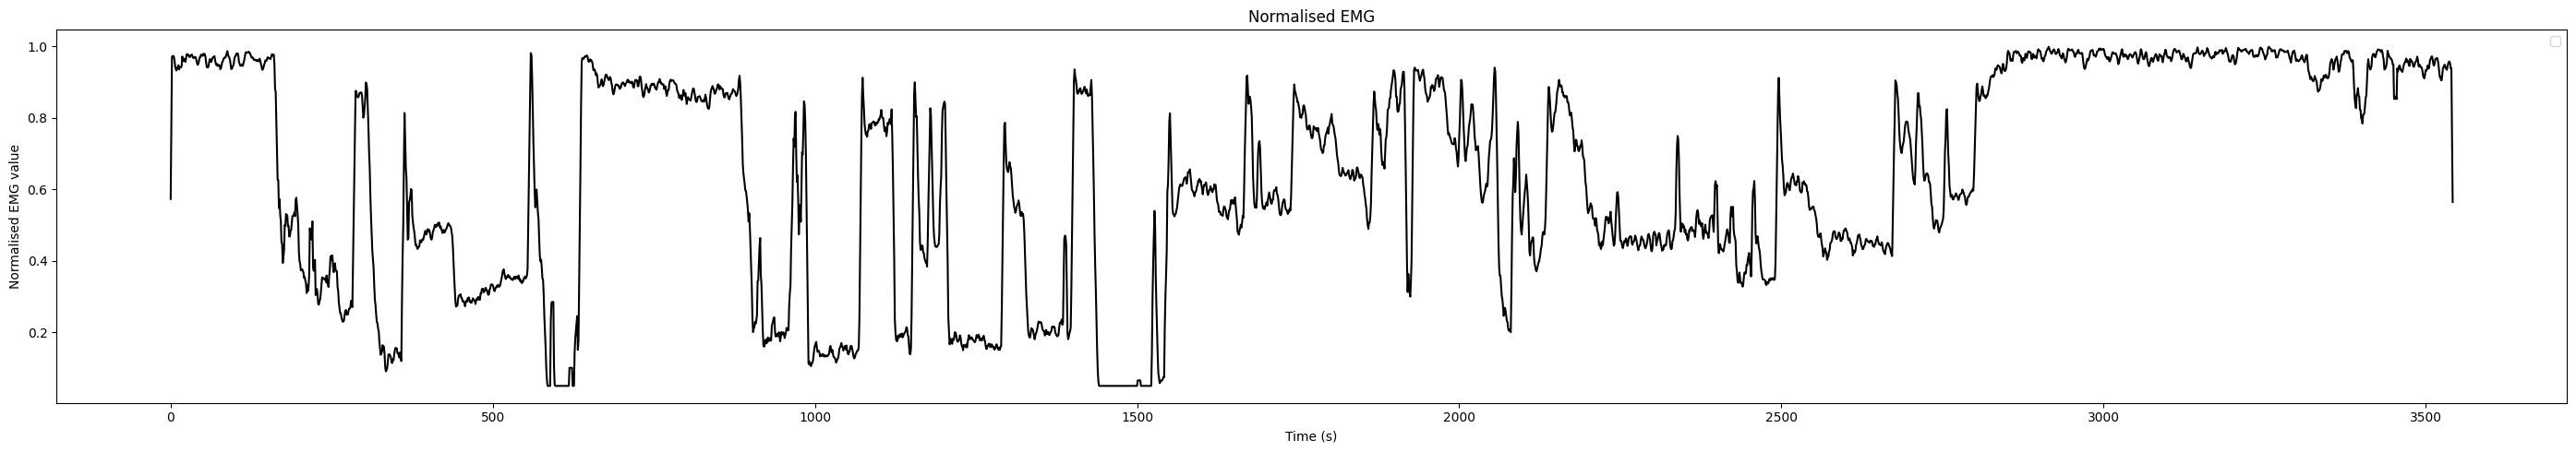

In [53]:
fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 5))
print(len(epochs))
print(len(emg_smoothed))
z = len(emg_smoothed) - len(epochs)
print(z)
n_z = len(epochs) - len(emg_smoothed)
print(n_z)

ax1.plot(epochs, emg_smoothed, label='', color = 'black')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Normalised EMG value")

# Add legends
ax1.legend()
ax1.set_title('Normalised EMG')
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(os.path.join(output_path, "normalized_emg.svg"), format="svg")

# Show the plots
plt.show()

##### Old vs new EMG figure for thesis

In [54]:
# print(len(emg_smoothed))
# print(len(emg_smoothed_old))

# fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 10))

# # x = len(emg_smoothed) - len(epochs)
# n_x = len(epochs) - len(emg_smoothed_old)

# ax1.plot(epochs, emg_smoothed, label='RMS EMG', color = colors[0])
# ### uncomment for comparison
# ax1.plot(epochs, emg_smoothed_old[:n_x], label='Raw EMG', color = colors[1])
# ax2.plot(epochs, majority_scores, label='', color='black')

# ax1.set_xlabel("Time (s)", fontsize=ax_label_font)
# ax1.set_ylabel("Normalised EMG", fontsize=ax_label_font)

# ax2.set_title('Manual Scoring', fontsize=ax_label_font)

# ax2.set_ylabel('States', fontsize=ax_label_font)
# ax2.set_xlabel('Time (s)', fontsize=ax_label_font)

# # mask the y-axis values with actual sleep stages
# ax2.set_yticks(ticks=[0, 1, 2, 3, 4], labels=["Wake", "N1", "N2", "N3", "REM"], fontsize=ax_tick_font)
# ax1.tick_params(axis="y", labelsize=ax_tick_font)
# ax2.invert_yaxis()

# # Add legends
# ax1.legend(fontsize=14)
# ax1.set_title(f'Raw EMG vs. Enveloped rms EMG - {subject}', fontsize=title_font, 
#         fontweight="bold")
# ax1.grid(axis="y")
# ax1.set_axisbelow(True)
# ax2.grid(axis="y")
# ax2.set_axisbelow(True)
# # Adjust layout to avoid overlap
# plt.tight_layout()
# plt.savefig(os.path.join(output_path, "normalized_emg.svg"), format="svg")

# # Show the plots
# plt.show()

In [55]:
print(len(emg_smoothed))
# print(len(emg_smoothed_old[:n_x]))

3543


##### Saving files for comparing old vs new EMG (obsolete now)

In [56]:
# from scipy.io import savemat

# savemat(
#     r"C:\Users\andri\school\bio-informatics\internship\donders\thesis_images\old_vs_new\new_emg_test.mat",
#     {"EMG": emg_smoothed}
# )
# savemat(
#     r"C:\Users\andri\school\bio-informatics\internship\donders\thesis_images\old_vs_new\old_emg_test.mat",
#     {"EMG": emg_smoothed_old[:n_x]}
# )
# savemat(
#     r"C:\Users\andri\school\bio-informatics\internship\donders\thesis_images\old_vs_new\hpyno_test.mat",
#     {"states": majority_scores}
# )

C:\Users\andri\AppData\Local\Temp\ipykernel_26012\2595268779.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\andri\AppData\Local\Temp\ipykernel_26012\2595268779.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
C:\Users\andri\AppData\Local\Temp\ipykernel_26012\2595268779.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


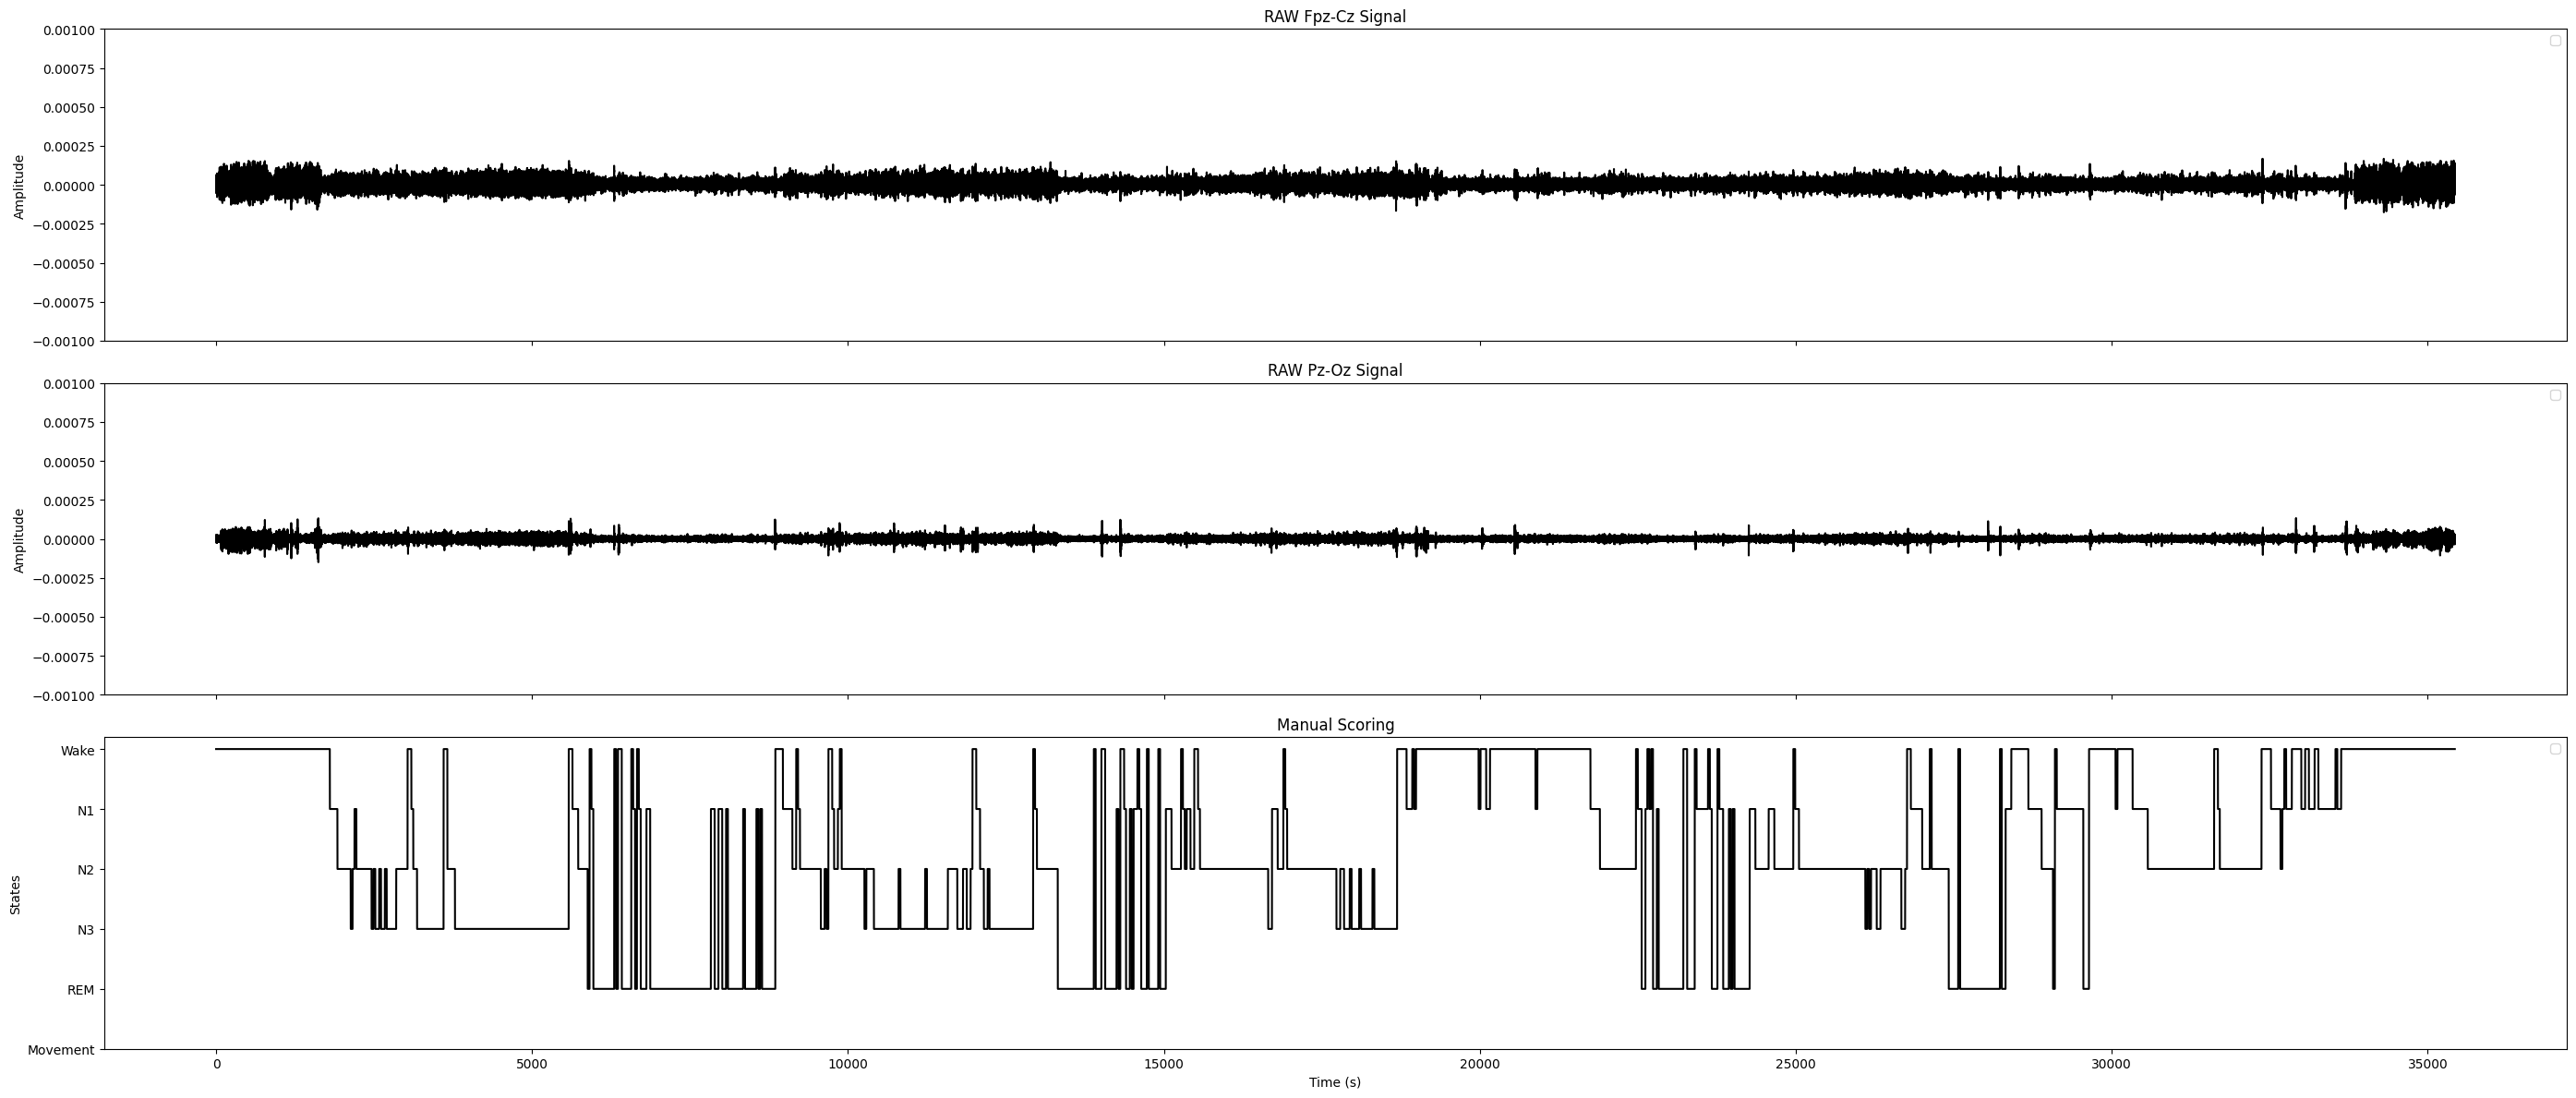

In [57]:
#upsampled_states = np.concatenate((upsampled_states, np.zeros(dif)), axis=0)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(28, 12))

# Plot data on each subplot
ax1.plot(x, raw_fpz, label='', color='black')
ax2.plot(x, raw_pz, label='', color='black')
ax3.plot(x, new_states, label='', color='black')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add axis titles
ax1.set_title('RAW Fpz-Cz Signal')
ax2.set_title('RAW Pz-Oz Signal')
ax3.set_title('Manual Scoring')

ax1.set_ylabel('Amplitude')
ax2.set_ylabel('Amplitude')
ax3.set_ylabel('States')
ax3.set_xlabel('Time (s)')

# Set y-axis limits (example values, adjust as needed)
ax1.set_ylim(-0.001, 0.001)  # Replace with appropriate limits for your data
ax2.set_ylim(-0.001, 0.001)  # Replace with appropriate limits for your data

# mask the y-axis values with actual sleep stages
ax3.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax3.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "raw_signals.svg"), format = "svg")
# Show the plots
plt.show()

3543
3543
0


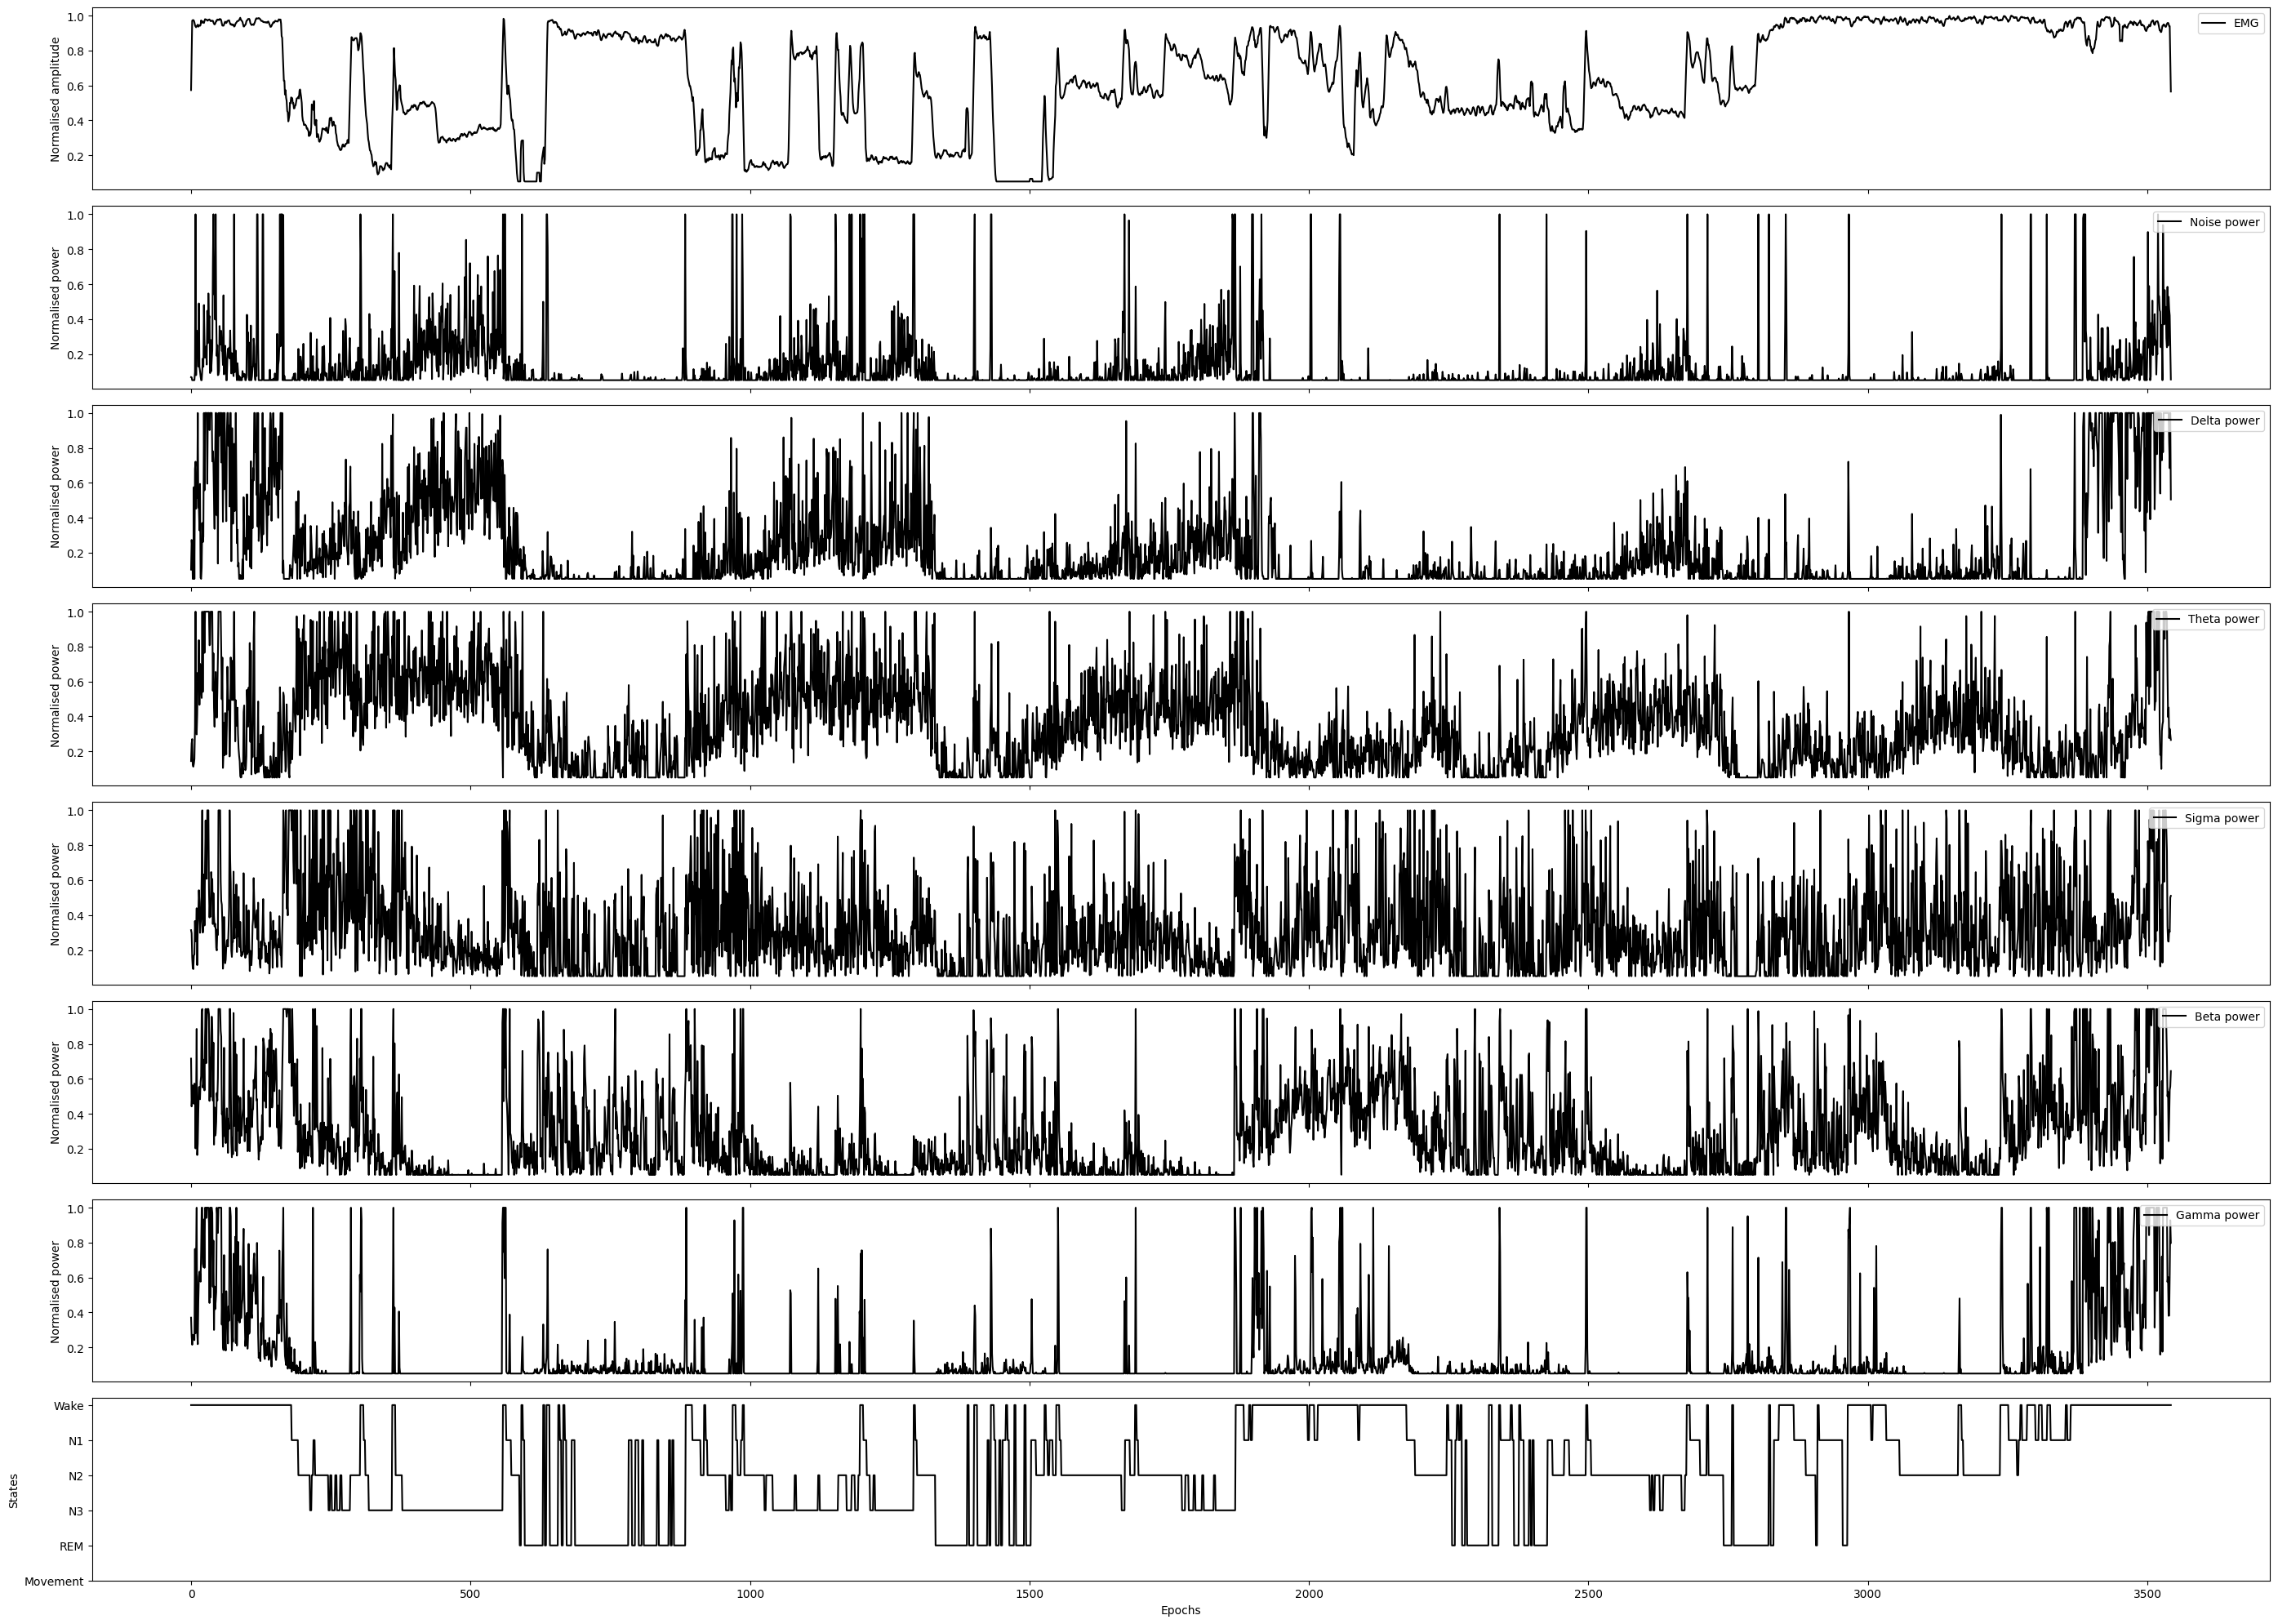

In [58]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8) = plt.subplots(8, 1, sharex=True, figsize = (28, 20))
# epochs = np.arange(len(EMG_norm))
print(len(emg_smoothed))
print(len(noise_norm))
print(dif)

# Plot data on each subplot
ax1.plot(epochs, emg_smoothed, label='EMG', color = 'black')
ax2.plot(epochs, noise_norm, label='Noise power', color = 'black')
ax3.plot(epochs, delta_norm, label='Delta power', color = 'black')
ax4.plot(epochs, theta_norm, label='Theta power', color = 'black')
ax5.plot(epochs, sigma_norm, label='Sigma power', color = 'black')
ax6.plot(epochs, beta_norm, label='Beta power', color = 'black')
ax7.plot(epochs, gamma_norm, label='Gamma power', color = 'black')
ax8.plot(epochs, majority_scores, label='Mapped scores', color = 'black')

ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
ax5.legend(loc='upper right')
ax6.legend(loc='upper right')
ax7.legend(loc='upper right')

ax1.set_ylabel('Normalised amplitude')
ax2.set_ylabel('Normalised power')
ax3.set_ylabel('Normalised power')
ax4.set_ylabel('Normalised power')
ax5.set_ylabel('Normalised power')
ax6.set_ylabel('Normalised power')
ax7.set_ylabel('Normalised power')
ax8.set_ylabel('States')

ax8.set_xlabel('Epochs')
ax8.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax8.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(os.path.join(output_path, "power_bands.svg"), format="svg")

# Show the plots
plt.show()

## Indices

### Wei indexes

#### Get indices

In [59]:
# Raw indices

index_w = index_W(delta_norm, gamma_norm, emg_smoothed)
index_n = index_N(delta_norm, sigma_norm, gamma_norm)
index_r = index_R(delta_norm, theta_norm, sigma_norm, emg_smoothed)
index_1 = Index_1(delta_norm, gamma_norm, emg_smoothed)
index_2 = Index_2(delta_norm, theta_norm, sigma_norm)
index_3 = Index_3(delta_norm, theta_norm, gamma_norm)
index_4 = Index_4(delta_norm, theta_norm)

# Taking the log of the indices

index_w_log = np.log(index_w)
index_n_log = np.log(index_n)
index_r_log = np.log(index_r)
index_1_log = np.log(index_1)
index_2_log = np.log(index_2)
index_3_log = np.log(index_3)
index_4_log = np.log(index_4)

# Normalizing the indices

index_w_norm = wei_normalizing(index_w_log)
index_n_norm = wei_normalizing(index_n_log)
index_r_norm = wei_normalizing(index_r_log)
index_1_norm = wei_normalizing(index_1_log)
index_2_norm = wei_normalizing(index_2_log)
index_3_norm = wei_normalizing(index_3_log)
index_4_norm = wei_normalizing(index_4_log)

# Smoothing the indices

index_w_smoothed = np.convolve(np.convolve(np.convolve(index_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_n_smoothed = np.convolve(np.convolve(np.convolve(index_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_r_smoothed = np.convolve(np.convolve(np.convolve(index_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_1_smoothed = np.convolve(np.convolve(np.convolve(index_1_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_2_smoothed = np.convolve(np.convolve(np.convolve(index_2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_3_smoothed = np.convolve(np.convolve(np.convolve(index_3_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_4_smoothed = np.convolve(np.convolve(np.convolve(index_4_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

#### Save wei features matrix

In [60]:
wei_features = np.column_stack((index_w_smoothed, index_n_smoothed, index_r_smoothed, index_1_smoothed, index_2_smoothed, index_3_smoothed, index_4_smoothed, noise_smoothed, theta_smoothed, delta_smoothed))
#np.save('Wei_features.npy', wei_features)

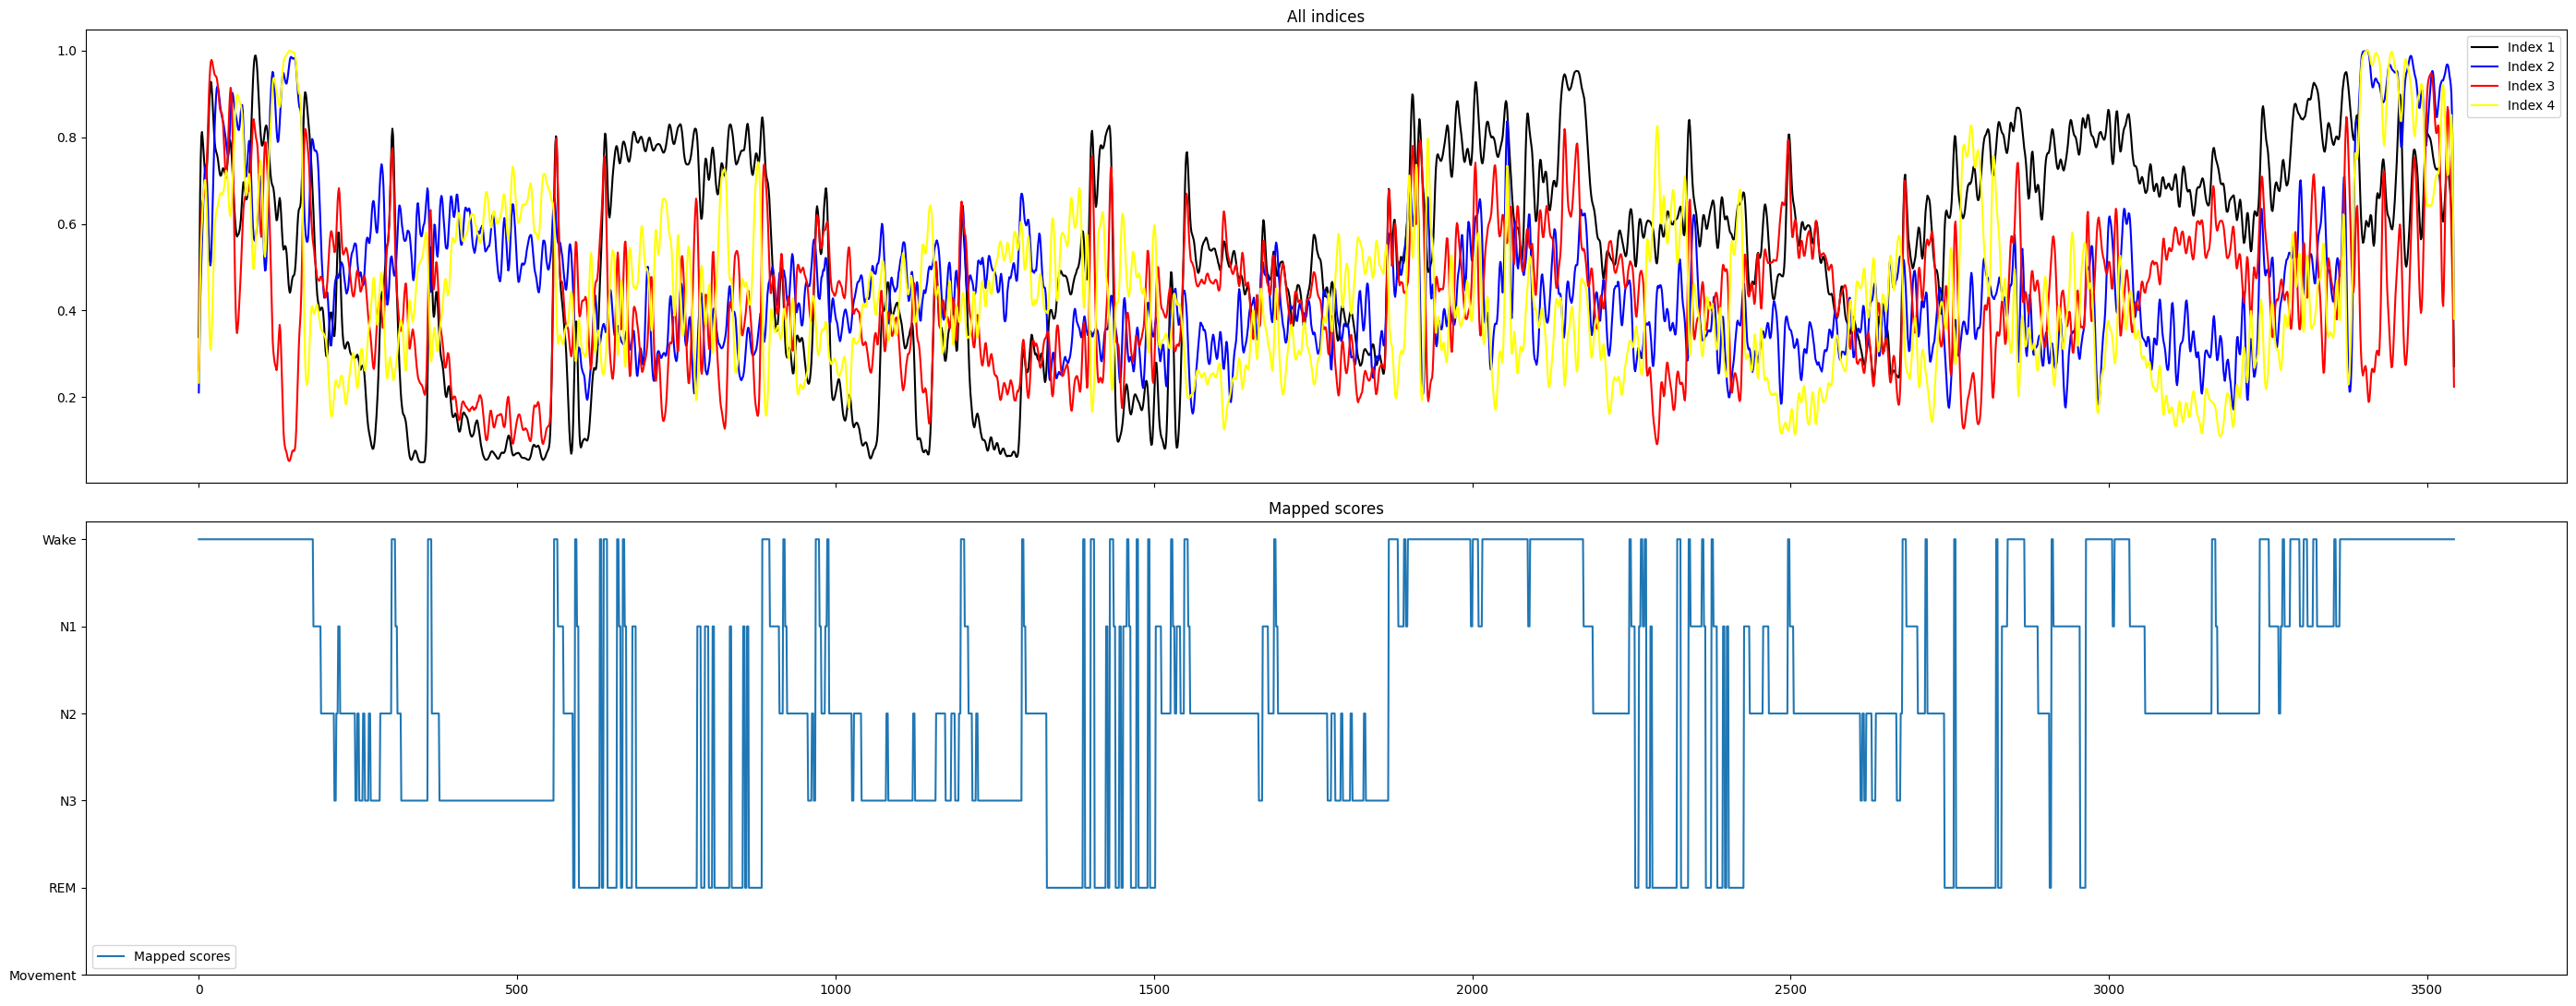

In [61]:
# All additional indices

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 11))

# Plot data on each subplot
ax1.plot(epochs, index_1_smoothed, label='Index 1', color='black')
ax1.plot(epochs, index_2_smoothed, label='Index 2', color='blue')
ax1.plot(epochs, index_3_smoothed, label='Index 3', color='red')
ax1.plot(epochs, index_4_smoothed, label='Index 4', color='Yellow')
ax2.plot(epochs, majority_scores, label='Mapped scores')


# Add legends
ax1.legend()
ax2.legend()


# Add titles
ax1.set_title('All indices')
ax2.set_title('Mapped scores')

ax2.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax2.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "extra-indices.svg"), format="svg")
# Show the plots
plt.show()

In [62]:
# Wei
index_Wake = [[],[],[],[]]
index_N1 = [[],[],[],[]]
index_N2 = [[],[],[],[]]
index_N3 = [[],[],[],[]]
index_REM = [[],[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_1_smoothed[i])
    index_Wake[1].append(index_2_smoothed[i])
    index_Wake[2].append(index_3_smoothed[i])
    index_Wake[3].append(index_4_smoothed[i])

  elif el == 'N1':
    index_N1[0].append(index_1_smoothed[i])
    index_N1[1].append(index_2_smoothed[i])
    index_N1[2].append(index_3_smoothed[i])
    index_N1[3].append(index_4_smoothed[i])

  elif el == 'N2':
    index_N2[0].append(index_1_smoothed[i])
    index_N2[1].append(index_2_smoothed[i])
    index_N2[2].append(index_3_smoothed[i])
    index_N2[3].append(index_4_smoothed[i])

  elif el == 'N3':
    index_N3[0].append(index_1_smoothed[i])
    index_N3[1].append(index_2_smoothed[i])
    index_N3[2].append(index_3_smoothed[i])
    index_N3[3].append(index_4_smoothed[i])

  elif el == 'REM':
    index_REM[0].append(index_1_smoothed[i])
    index_REM[1].append(index_2_smoothed[i])
    index_REM[2].append(index_3_smoothed[i])
    index_REM[3].append(index_4_smoothed[i])

# Wei
wake_1 = np.average(index_Wake[0])
wake_2 = np.average(index_Wake[1])
wake_3 = np.average(index_Wake[2])
wake_4 = np.average(index_Wake[3])
N1_1 = np.average(index_N1[0])
N1_2 = np.average(index_N1[1])
N1_3 = np.average(index_N1[2])
N1_4 = np.average(index_N1[3])
N2_1 = np.average(index_N2[0])
N2_2 = np.average(index_N2[1])
N2_3 = np.average(index_N2[2])
N2_4 = np.average(index_N2[3])
N3_1 = np.average(index_N3[0])
N3_2 = np.average(index_N3[1])
N3_3 = np.average(index_N3[2])
N3_4 = np.average(index_N3[3])
REM_1 = np.average(index_REM[0])
REM_2 = np.average(index_REM[1])
REM_3 = np.average(index_REM[2])
REM_4 = np.average(index_REM[3])

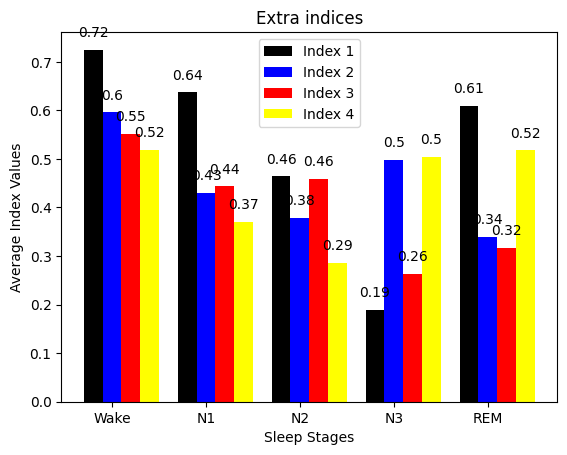

In [63]:
plt.subplot(1, 1, 1)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_1', 'Index_2', 'Index_3', 'Index_4']
values_1 = [wake_1, N1_1, N2_1, N3_1, REM_1]
values_2 = [wake_2, N1_2, N2_2, N3_2, REM_2]
values_3 = [wake_3, N1_3, N2_3, N3_3, REM_3]
values_4 = [wake_4, N1_4, N2_4, N3_4, REM_4]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_1, width=bar_width, label='Index 1', color = 'black')
plt.bar(x, values_2, width=bar_width, label='Index 2', color = 'blue',)
plt.bar(x + bar_width, values_3, width=bar_width, label='Index 3', color = 'red')
plt.bar(x +  (2 * bar_width), values_4, width=bar_width, label='Index 4', color = 'yellow')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Extra indices')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_1[i] + 0.02, str(round(values_1[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_2[i] + 0.02, str(round(values_2[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_3[i] + 0.02, str(round(values_3[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + (2 * bar_width), values_4[i] + 0.02, str(round(values_4[i], 2)), ha='center', va='bottom')

plt.savefig(os.path.join(output_path, "extra_indices_barplot.svg"), format="svg")

#### Main indices plots

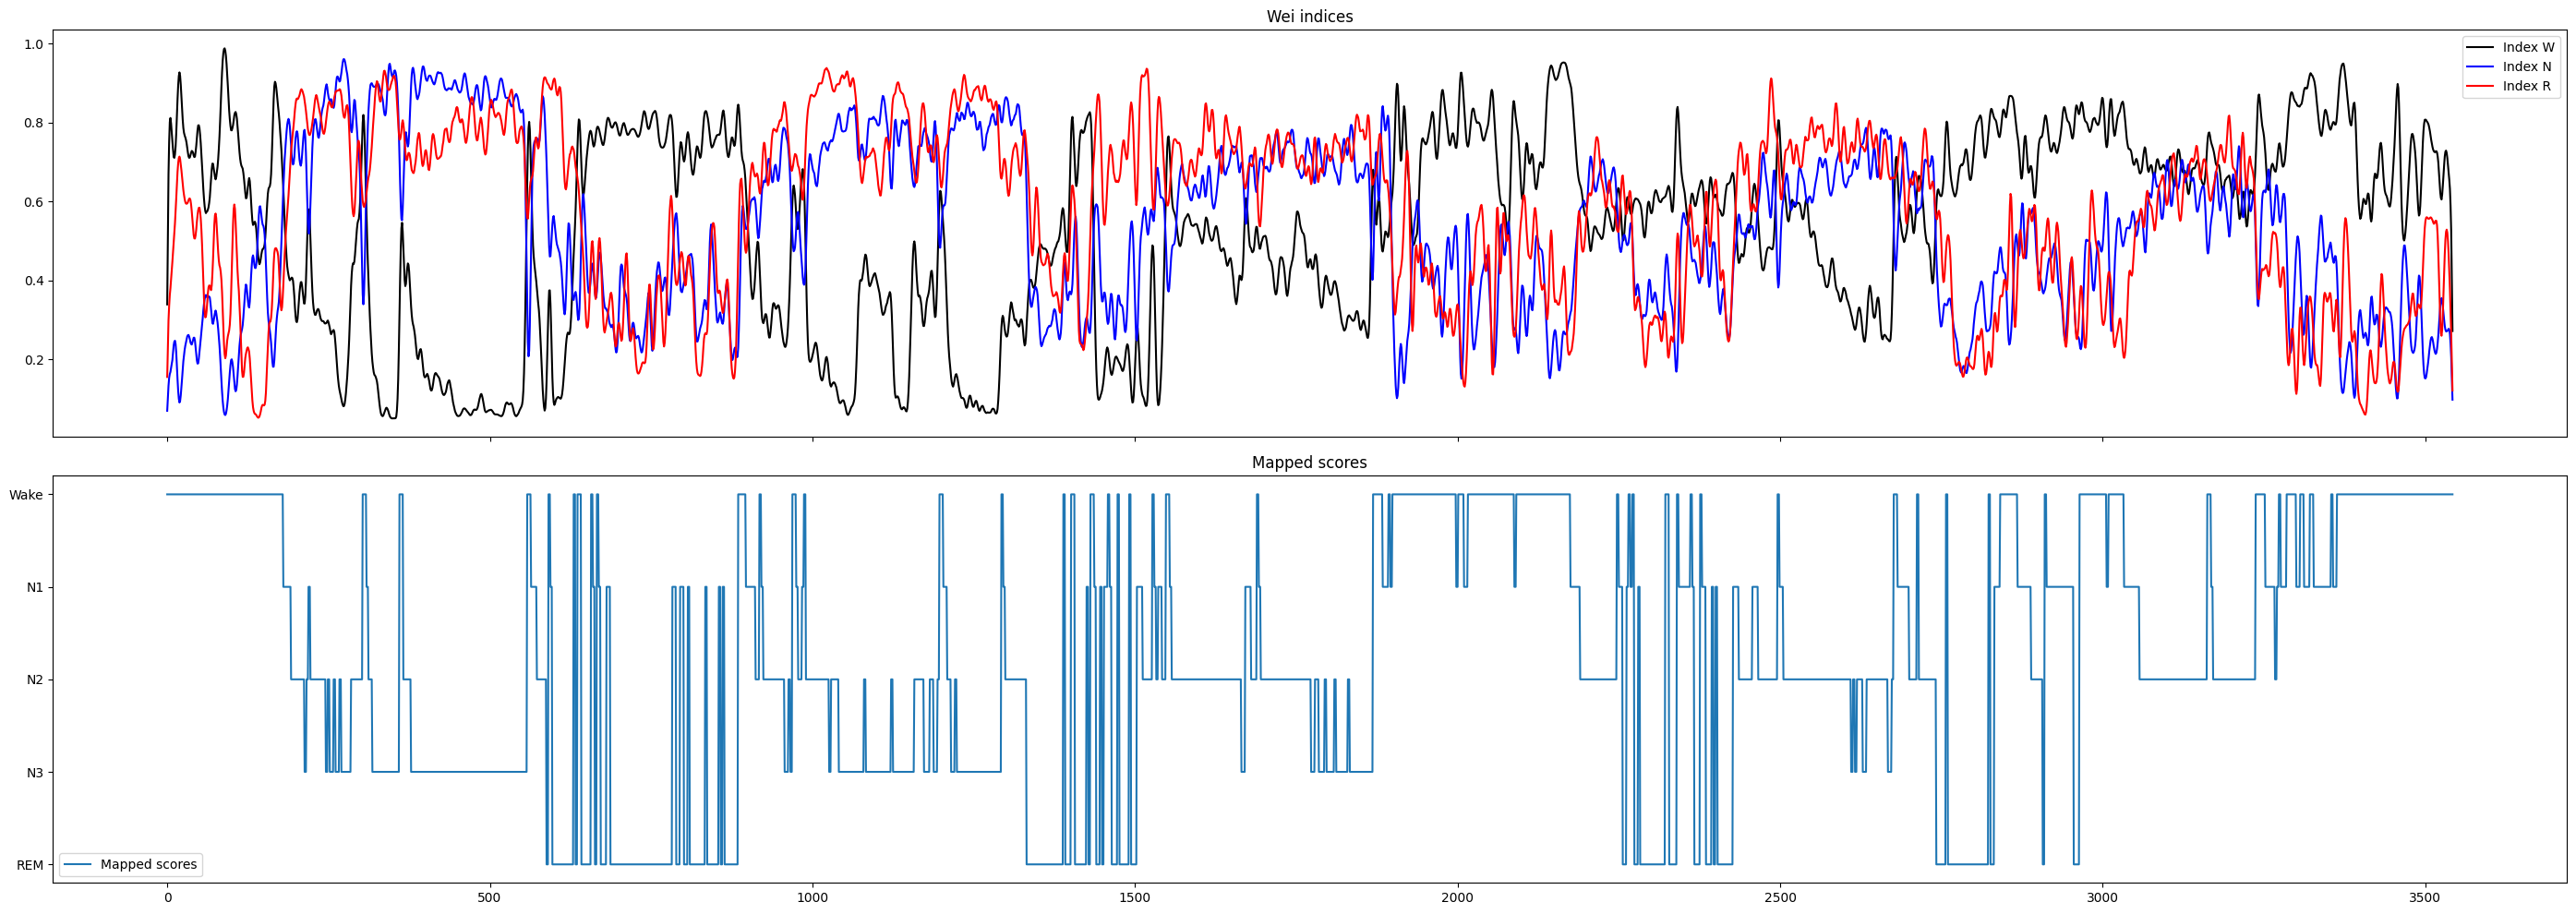

In [64]:
# All main indices

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 10))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color='red')

ax2.plot(epochs, majority_scores, label='Mapped scores')


# Add legends
ax1.legend()
ax2.legend()


# Add titles
ax1.set_title('Wei indices')
ax2.set_title('Mapped scores')

ax2.set_yticks(ticks=[0, 1, 2, 3, 4], labels=["Wake", "N1", "N2", "N3", "REM"])
ax2.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "wei_all-indices.svg"), format="svg")
# Show the plots
plt.show()

### New indexes

#### New WAKE (define and get index)

##### Compute new index + function

In [65]:
nindex_w = nindex_W(theta_norm, gamma_norm, emg_smoothed)
nindex_w_log = np.log(nindex_w)
nindex_w_norm = wei_normalizing(nindex_w_log)
nindex_w_smoothed = np.convolve(np.convolve(np.convolve(nindex_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [67]:
# nindex_w_old = nindex_W(theta_norm, gamma_norm, emg_smoothed_old)
# nindex_w_log_old = np.log(nindex_w_old)
# nindex_w_norm_old = wei_normalizing(nindex_w_log_old)
# nindex_w_smoothed_old = np.convolve(np.convolve(np.convolve(nindex_w_norm_old, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

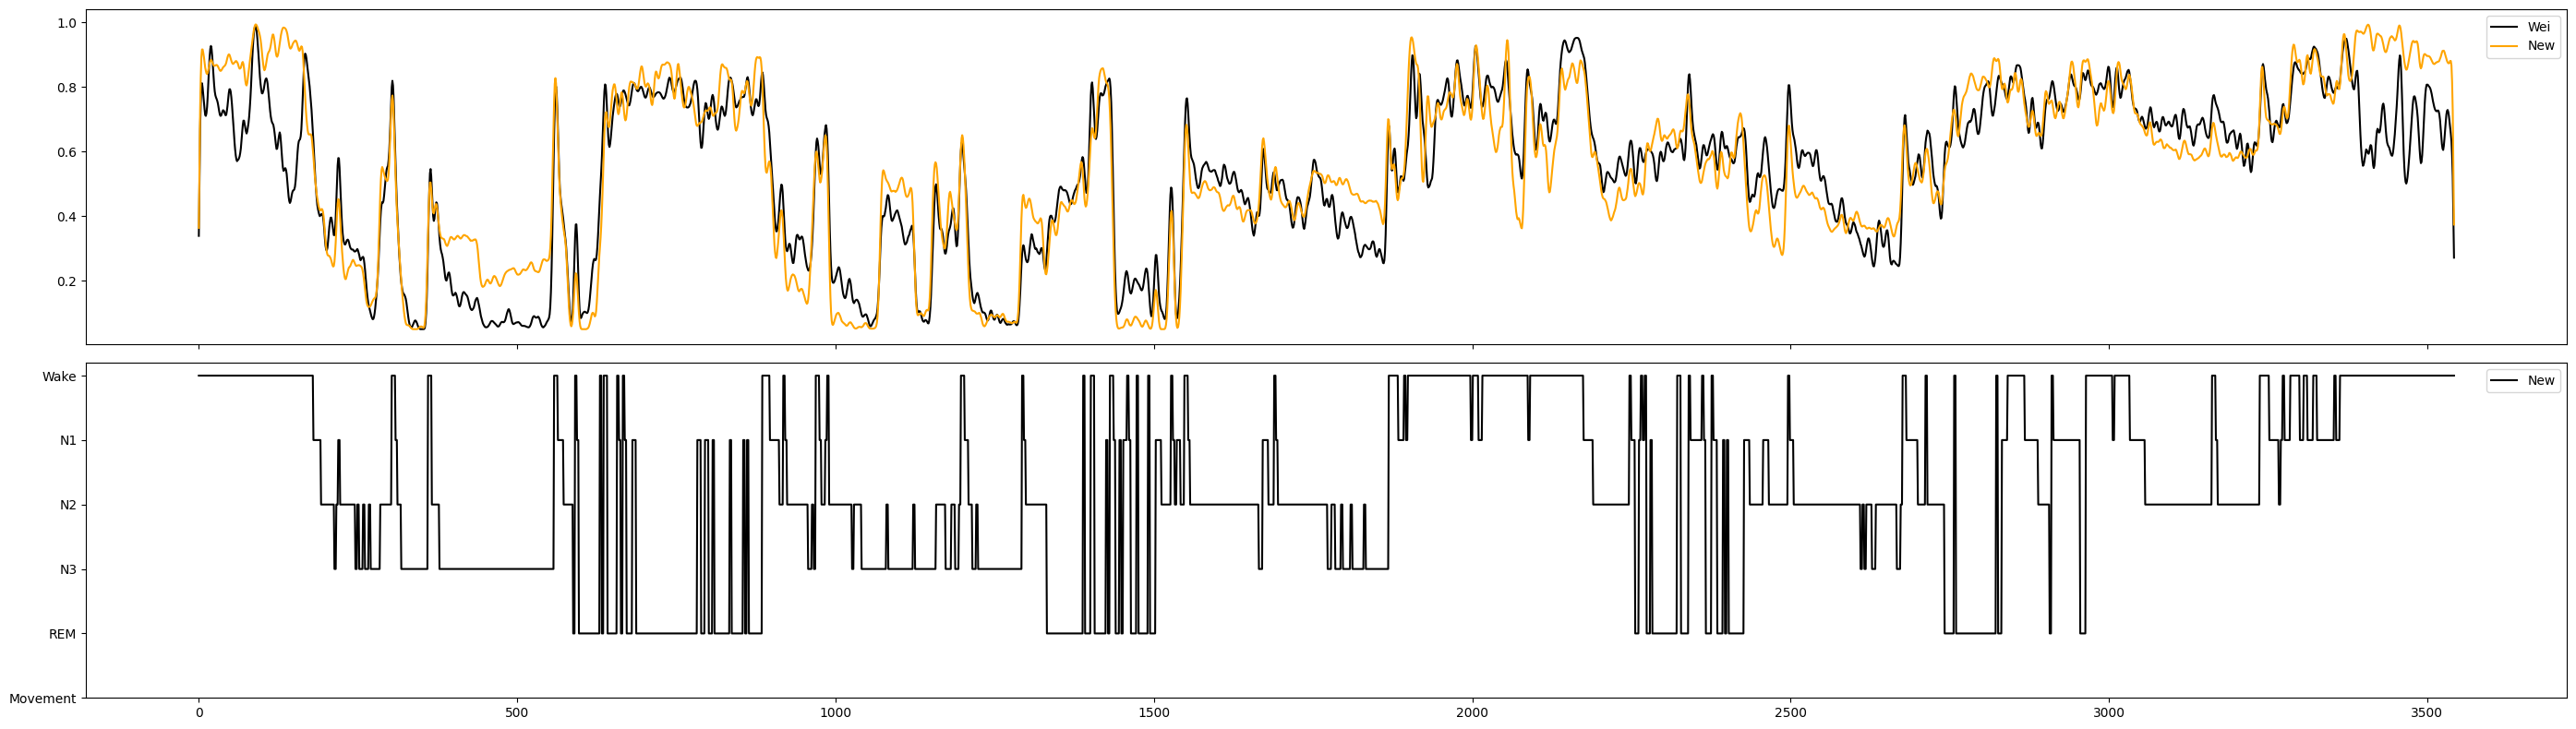

In [68]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_w_smoothed, label='New', color = 'orange')
ax2.plot(epochs, majority_scores, label='New', color = 'black')

# Add legends
ax1.legend()
ax2.legend()

ax2.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax2.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "index-w_wei-vs-new.svg"), format="svg")
# Show the plots
plt.show()

##### All indices plot

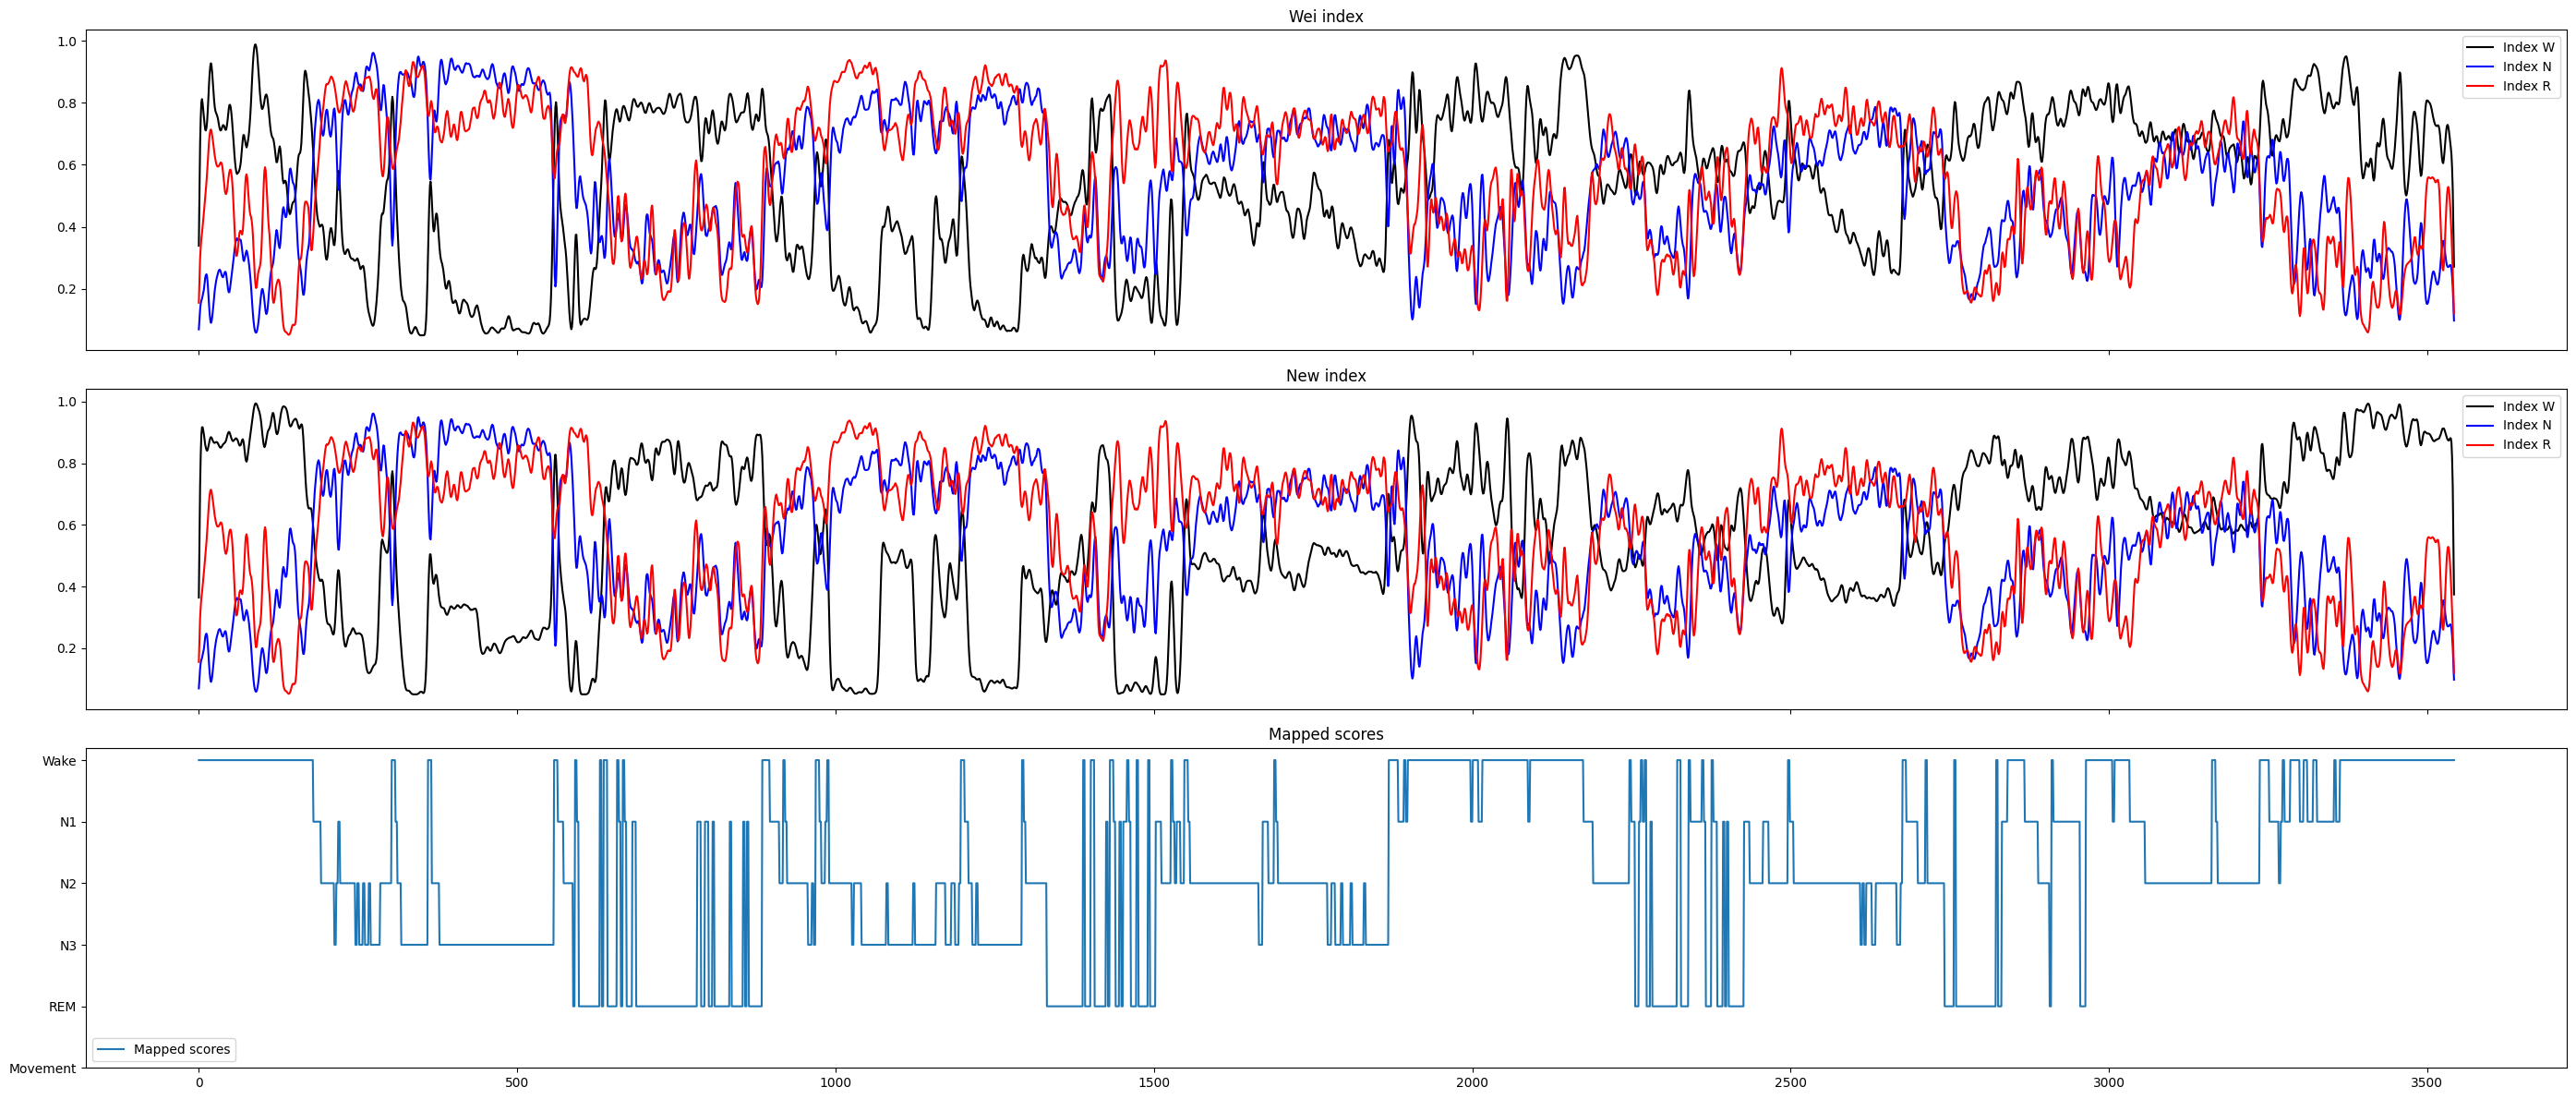

In [69]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, nindex_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, index_r_smoothed, label='Index R', color ='red')


ax3.plot(epochs, majority_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')

ax3.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax3.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "index-w_wei-vs-new_all-indices.svg"), format="svg")

# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [70]:
# Wei
index_Wake = [[],[],[]]
index_N1 = [[],[],[]]
index_N2 = [[],[],[]]
index_N3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_N1[0].append(index_w_smoothed[i])
    index_N1[1].append(index_r_smoothed[i])
    index_N1[2].append(index_n_smoothed[i])

  elif el == 'N2':
    index_N2[0].append(index_w_smoothed[i])
    index_N2[1].append(index_r_smoothed[i])
    index_N2[2].append(index_n_smoothed[i])

  elif el == 'N3':
    index_N3[0].append(index_w_smoothed[i])
    index_N3[1].append(index_r_smoothed[i])
    index_N3[2].append(index_n_smoothed[i])

  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_N1 = [[],[],[]]
nindex_N2 = [[],[],[]]
nindex_N3 = [[],[],[]]
nindex_REM = [[],[],[]]

for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(nindex_w_smoothed[i])
    nindex_Wake[1].append(index_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_N1[0].append(nindex_w_smoothed[i])
    nindex_N1[1].append(index_r_smoothed[i])
    nindex_N1[2].append(index_n_smoothed[i])

  elif el == 'N2':
    nindex_N2[0].append(nindex_w_smoothed[i])
    nindex_N2[1].append(index_r_smoothed[i])
    nindex_N2[2].append(index_n_smoothed[i])

  elif el == 'N3':
    nindex_N3[0].append(nindex_w_smoothed[i])
    nindex_N3[1].append(index_r_smoothed[i])
    nindex_N3[2].append(index_n_smoothed[i])

  elif el == 'REM':
    nindex_REM[0].append(nindex_w_smoothed[i])
    nindex_REM[1].append(index_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
N1_w = np.average(index_N1[0])
N1_r = np.average(index_N1[1])
N1_n = np.average(index_N1[2])
N2_w = np.average(index_N2[0])
N2_r = np.average(index_N2[1])
N2_n = np.average(index_N2[2])
N3_w = np.average(index_N3[0])
N3_r = np.average(index_N3[1])
N3_n = np.average(index_N3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nN1_w = np.average(nindex_N1[0])
nN1_r = np.average(nindex_N1[1])
nN1_n = np.average(nindex_N1[2])
nN2_w = np.average(nindex_N2[0])
nN2_r = np.average(nindex_N2[1])
nN2_n = np.average(nindex_N2[2])
nN3_w = np.average(nindex_N3[0])
nN3_r = np.average(nindex_N3[1])
nN3_n = np.average(nindex_N3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

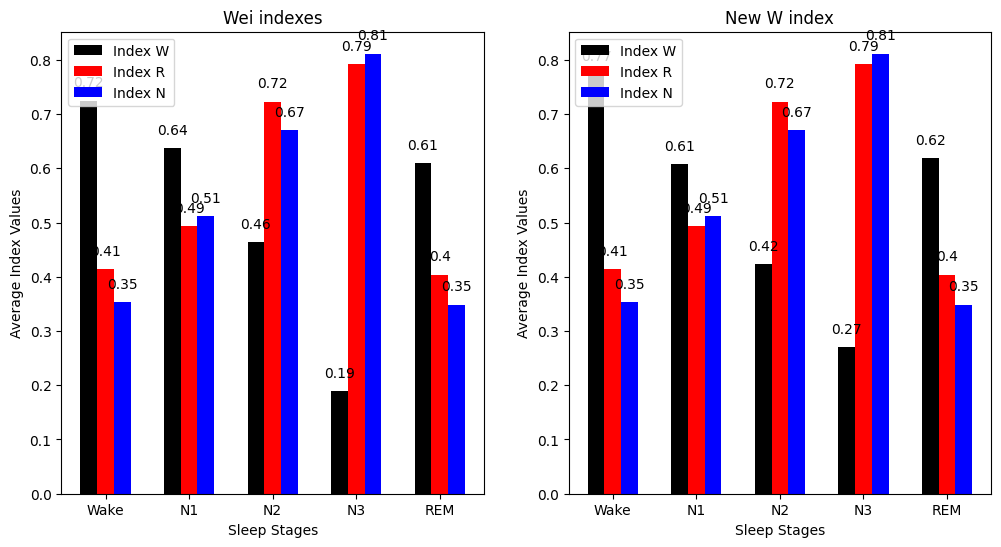

In [71]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2', 'N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, N1_w, N2_w, N3_w, REM_w]
values_REM = [wake_r, N1_r, N2_r, N3_r, REM_r]
values_NREM = [wake_n, N1_n, N2_n, N3_n,REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')




# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nN1_w, nN2_w, nN3_w, nREM_w]
values_REM = [nwake_r, nN1_r, nN2_r, nN3_r, nREM_r]
values_NREM = [nwake_n, nN1_n, nN2_n, nN3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New W index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

plt.savefig(os.path.join(output_path, "index-w_wei-vs-new_all-indices_barplot.svg"), format="svg")

In [73]:
# # old
# index_Wake = [[]]
# index_N1 = [[]]
# index_N2 = [[]]
# index_N3 = [[]]
# index_REM = [[]]
# # new
# nindex_Wake = [[]]
# nindex_N1 = [[]]
# nindex_N2 = [[]]
# nindex_N3 = [[]]
# nindex_REM = [[]]

# for i, el in enumerate(mapped_scores):

#   if el == 'Wake':
#     index_Wake[0].append(nindex_w_smoothed_old[i])
#     nindex_Wake[0].append(nindex_w_smoothed[i])

#   elif el == 'N1':
#     index_N1[0].append(nindex_w_smoothed_old[i])
#     nindex_N1[0].append(nindex_w_smoothed[i])

#   elif el == 'N2':
#     index_N2[0].append(nindex_w_smoothed_old[i])
#     nindex_N2[0].append(nindex_w_smoothed[i])

#   elif el == 'N3':
#     index_N3[0].append(nindex_w_smoothed_old[i])
#     nindex_N3[0].append(nindex_w_smoothed[i])

#   elif el == 'REM':
#     index_REM[0].append(nindex_w_smoothed_old[i])
#     nindex_REM[0].append(nindex_w_smoothed[i])

  
# # old
# wake_w = np.average(index_Wake[0])
# N1_w = np.average(index_N1[0])
# N2_w = np.average(index_N2[0])
# N3_w = np.average(index_N3[0])
# REM_w = np.average(index_REM[0])

# # New
# nwake_w = np.average(nindex_Wake[0])
# nN1_w = np.average(nindex_N1[0])
# nN2_w = np.average(nindex_N2[0])
# nN3_w = np.average(nindex_N3[0])
# nREM_w = np.average(nindex_REM[0])

# # old
# sem_wake_w = sem(index_Wake[0])
# sem_N1_w = sem(index_N1[0])
# sem_N2_w = sem(index_N2[0])
# sem_N3_w = sem(index_N3[0])
# sem_REM_w = sem(index_REM[0])

# # New
# sem_nwake_w = sem(nindex_Wake[0])
# sem_nN1_w = sem(nindex_N1[0])
# sem_nN2_w = sem(nindex_N2[0])
# sem_nN3_w = sem(nindex_N3[0])
# sem_nREM_w = sem(nindex_REM[0])

##### Figure for plotting index w with old and new EMG (obsolete now)

In [74]:
# plt.figure(figsize=(6, 6))

# # Wei indexes
# plt.subplot(1, 1, 1)
# categories = ['Wake', 'N1', 'N2', 'N3', 'REM']
# index_types = ['old Index_w', 'new Index_W']
# values_old_wake = [wake_w, N1_w, N2_w, N3_w, REM_w]
# values_new_wake = [nwake_w, nN1_w, nN2_w, nN3_w, nREM_w]
# sem_old_wake = [sem_wake_w, sem_N1_w, sem_N2_w, sem_N3_w, sem_REM_w]
# sem_new_wake = [sem_nwake_w, sem_nN1_w, sem_nN2_w, sem_nN3_w, sem_nREM_w]
# x = np.arange(len(categories))
# bar_width = 0.3
# # Create bar plots
# plt.bar(x-(0.5*bar_width), values_old_wake, width=bar_width, label='Raw EMG', color = colors[1], zorder=2, yerr=sem_old_wake, capsize=5)
# plt.bar(x+(0.5*bar_width), values_new_wake, width=bar_width, label='rms EMG', color = colors[0], zorder=2, yerr=sem_new_wake, capsize=5)
# # Add labels and title
# plt.xlabel('Sleep Stages', fontsize=ax_label_font)
# plt.ylabel('Average Index Values', fontsize=ax_label_font)
# plt.title('Raw EMG vs. Enveloped rms EMG effects\nindex W', fontsize=subtitle_font,fontweight="bold")
# plt.xticks(x, categories, fontsize=ax_tick_font)
# plt.tick_params(axis="y", labelsize=ax_tick_font)
# plt.legend()
# plt.grid(axis="y", zorder=0)
# plt.ylim(0, 1)

# for i in range(len(categories)):
#     plt.text(x[i] - (0.5*bar_width), values_old_wake[i] + 0.02, str(round(values_old_wake[i], 2)), ha='center', va='bottom', fontsize=ax_tick_font, rotation=90)
#     plt.text(x[i] + (0.5*bar_width), values_new_wake[i] + 0.02, str(round(values_new_wake[i], 2)), ha='center', va='bottom', fontsize=ax_tick_font, rotation=90)

# plt.savefig(os.path.join(output_path, "emg_effect_wake.svg"), format="svg")

#### New REM (define and get index)

##### Compute new index + function

In [75]:
nindex_r = nindex_R(delta_norm, theta_norm, sigma_norm, emg_smoothed, gamma_norm)
nindex_r_log = np.log(nindex_r)
nindex_r_norm = wei_normalizing(nindex_r_log)
nindex_r_smoothed = np.convolve(np.convolve(np.convolve(nindex_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [77]:
# nindex_r_old = nindex_R(delta_norm, theta_norm, sigma_norm, emg_smoothed_old, gamma_norm)
# nindex_r_log_old = np.log(nindex_r_old)
# nindex_r_norm_old = wei_normalizing(nindex_r_log_old)
# nindex_r_smoothed_old = np.convolve(np.convolve(np.convolve(nindex_r_norm_old, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

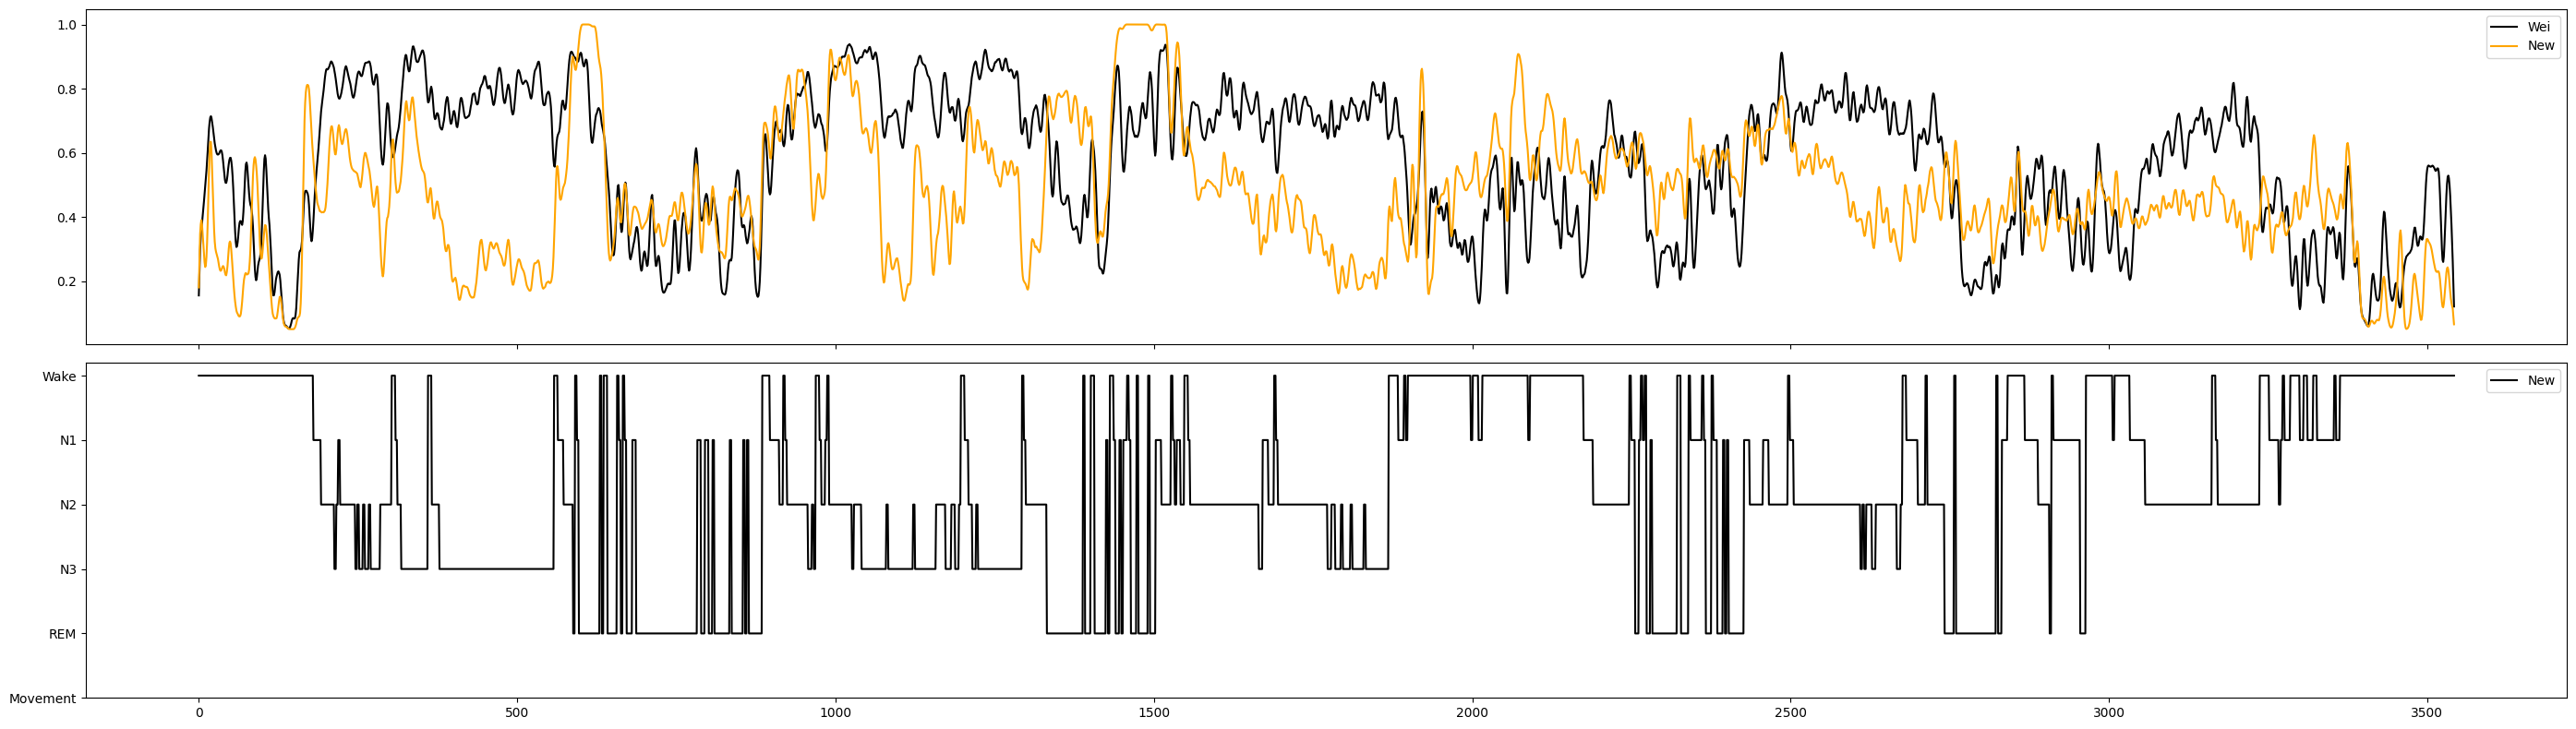

In [78]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_r_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_r_smoothed, label='New', color = 'orange')
ax2.plot(epochs, majority_scores, label='New', color = 'black')

# Add legends
ax1.legend()
ax2.legend()
ax2.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax2.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "index-r_wei-vs-new.svg"), format="svg")
# Show the plots
plt.show()

##### All indices plot

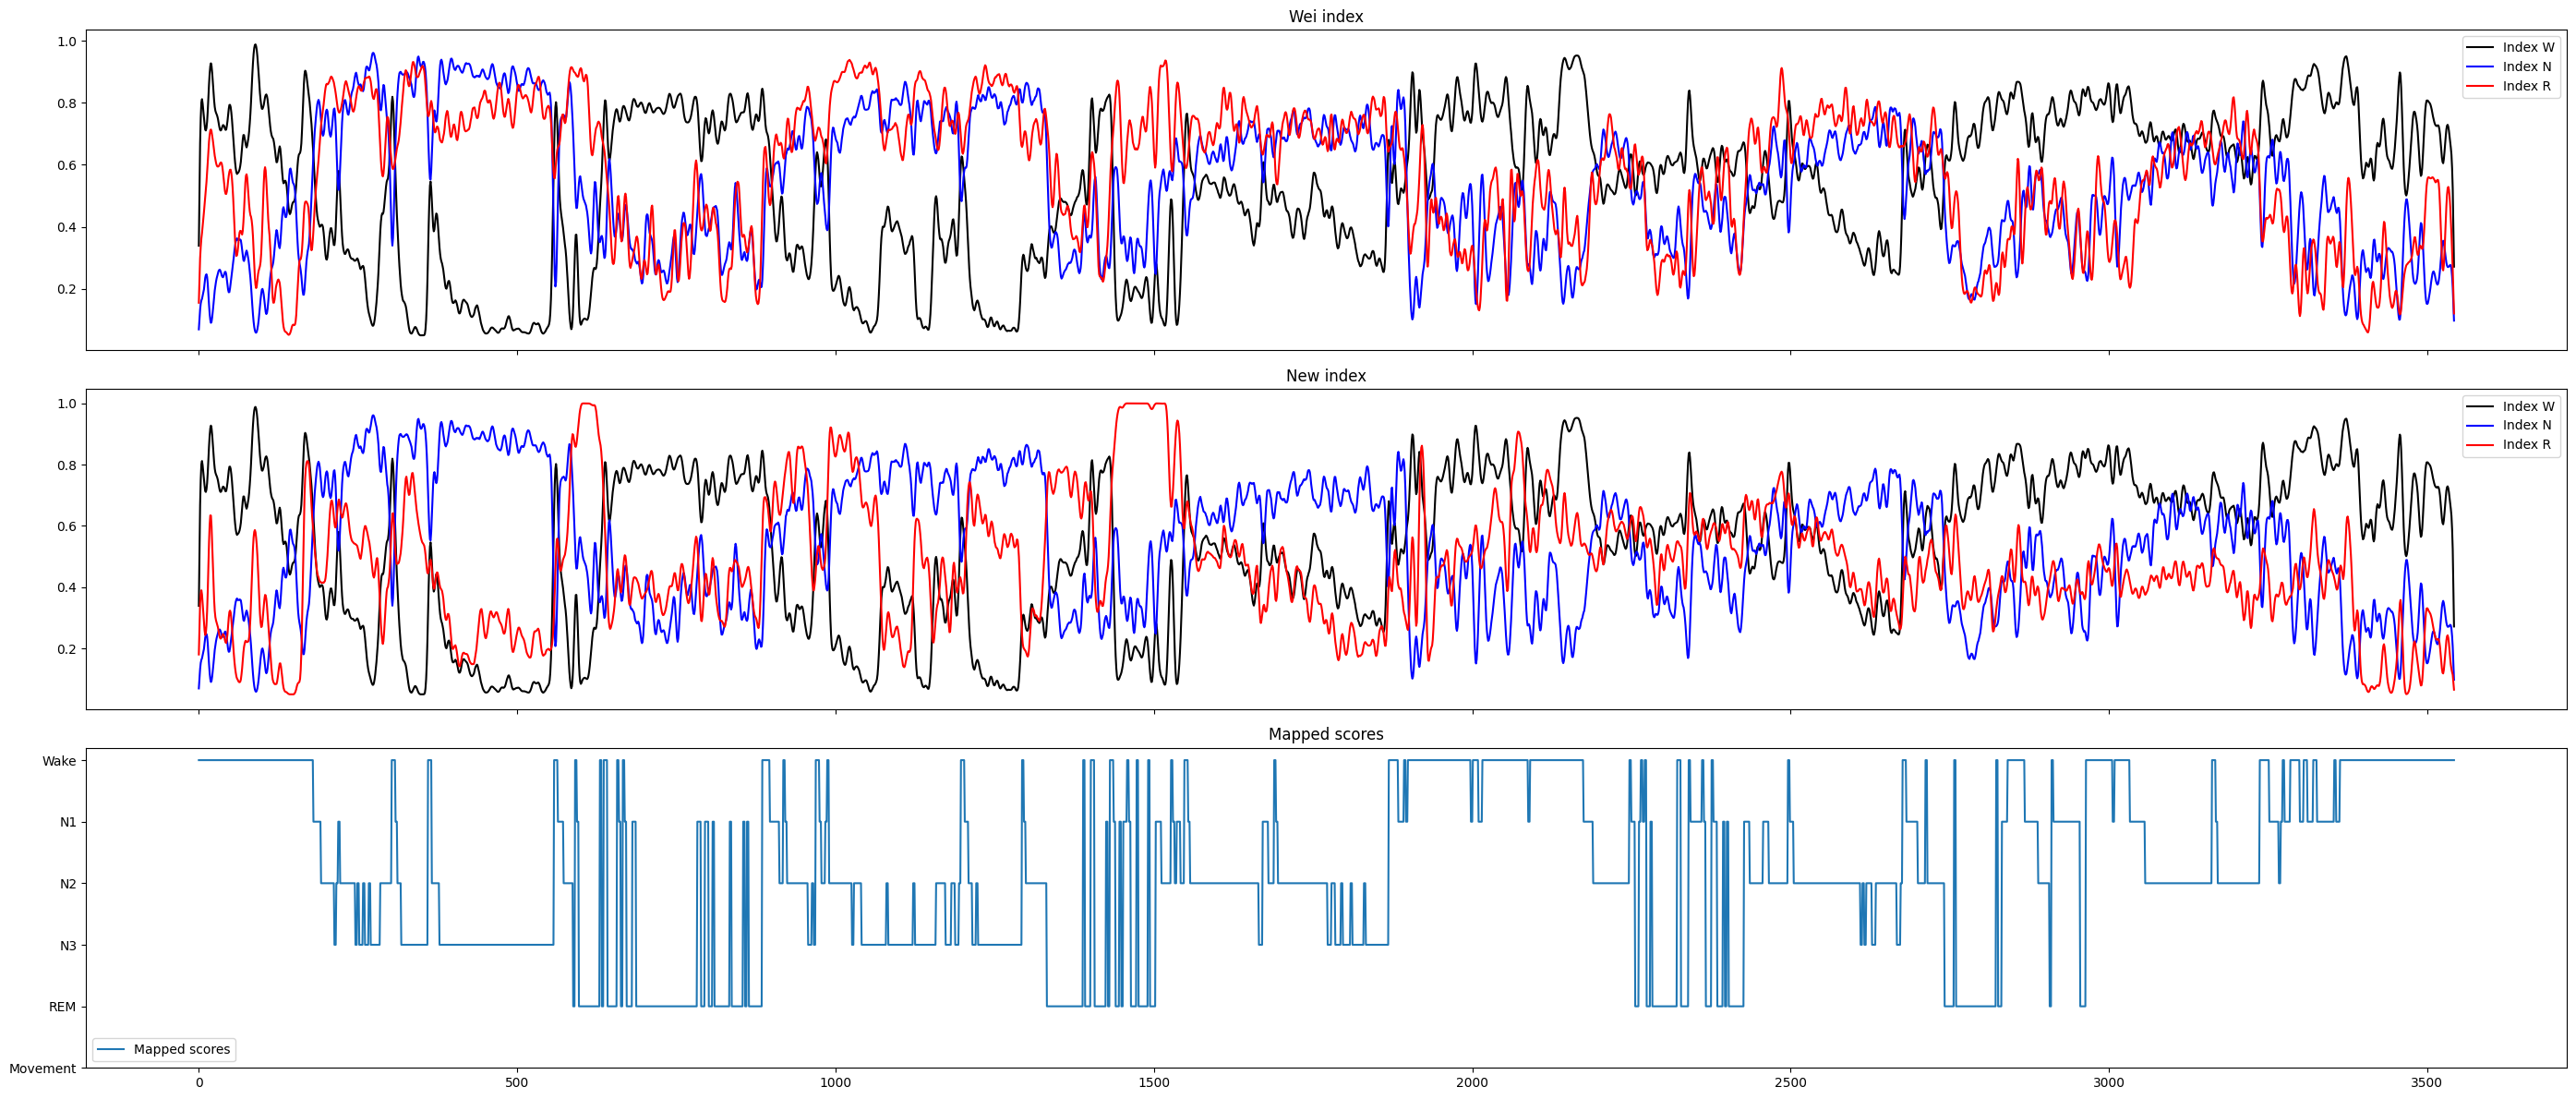

In [79]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, nindex_r_smoothed, label='Index R', color ='red')


ax3.plot(epochs, majority_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')
ax3.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax3.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "index-r_wei-vs-new_all-indices.svg"), format="svg")

# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [80]:
# New
nindex_Wake = [[],[],[]]
nindex_N1 = [[],[],[]]
nindex_N2 = [[],[],[]]
nindex_N3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(index_w_smoothed[i])
    nindex_Wake[1].append(nindex_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_N1[0].append(index_w_smoothed[i])
    nindex_N1[1].append(nindex_r_smoothed[i])
    nindex_N1[2].append(index_n_smoothed[i])

  elif el == 'N2':
    nindex_N2[0].append(index_w_smoothed[i])
    nindex_N2[1].append(nindex_r_smoothed[i])
    nindex_N2[2].append(index_n_smoothed[i])

  elif el == 'N3':
    nindex_N3[0].append(index_w_smoothed[i])
    nindex_N3[1].append(nindex_r_smoothed[i])
    nindex_N3[2].append(index_n_smoothed[i])

  elif el == 'REM':
    nindex_REM[0].append(index_w_smoothed[i])
    nindex_REM[1].append(nindex_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [81]:
# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nN1_w = np.average(nindex_N1[0])
nN1_r = np.average(nindex_N1[1])
nN1_n = np.average(nindex_N1[2])
nN2_w = np.average(nindex_N2[0])
nN2_r = np.average(nindex_N2[1])
nN2_n = np.average(nindex_N2[2])
nN3_w = np.average(nindex_N3[0])
nN3_r = np.average(nindex_N3[1])
nN3_n = np.average(nindex_N3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

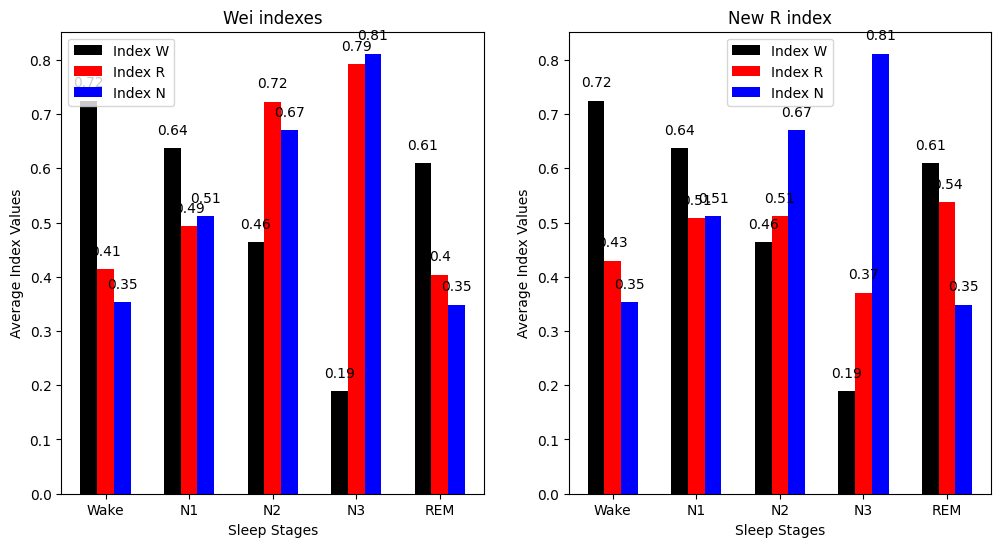

In [82]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, N1_w, N2_w, N3_w, REM_w]
values_REM = [wake_r, N1_r, N2_r, N3_r, REM_r]
values_NREM = [wake_n, N1_n, N2_n, N3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nN1_w, nN2_w, nN3_w, nREM_w]
values_REM = [nwake_r, nN1_r, nN2_r, nN3_r, nREM_r]
values_NREM = [nwake_n, nN1_n, nN2_n, nN3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New R index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

plt.savefig(os.path.join(output_path, "index-r_wei-vs-new_all-indices_barplot.svg"), format="svg")

In [84]:
# # old
# index_Wake = [[]]
# index_N1 = [[]]
# index_N2 = [[]]
# index_N3 = [[]]
# index_REM = [[]]
# # new
# nindex_Wake = [[]]
# nindex_N1 = [[]]
# nindex_N2 = [[]]
# nindex_N3 = [[]]
# nindex_REM = [[]]

# for i, el in enumerate(mapped_scores):

#   if el == 'Wake':
#     index_Wake[0].append(nindex_r_smoothed_old[i])
#     nindex_Wake[0].append(nindex_r_smoothed[i])

#   elif el == 'N1':
#     index_N1[0].append(nindex_r_smoothed_old[i])
#     nindex_N1[0].append(nindex_r_smoothed[i])

#   elif el == 'N2':
#     index_N2[0].append(nindex_r_smoothed_old[i])
#     nindex_N2[0].append(nindex_r_smoothed[i])

#   elif el == 'N3':
#     index_N3[0].append(nindex_r_smoothed_old[i])
#     nindex_N3[0].append(nindex_r_smoothed[i])

#   elif el == 'REM':
#     index_REM[0].append(nindex_r_smoothed_old[i])
#     nindex_REM[0].append(nindex_r_smoothed[i])

  
# # old
# wake_r = np.average(index_Wake[0])
# N1_r = np.average(index_N1[0])
# N2_r = np.average(index_N2[0])
# N3_r = np.average(index_N3[0])
# REM_r = np.average(index_REM[0])

# # New
# nwake_r = np.average(nindex_Wake[0])
# nN1_r = np.average(nindex_N1[0])
# nN2_r = np.average(nindex_N2[0])
# nN3_r = np.average(nindex_N3[0])
# nREM_r = np.average(nindex_REM[0])

# # old
# sem_wake_r = sem(index_Wake[0])
# sem_N1_r = sem(index_N1[0])
# sem_N2_r = sem(index_N2[0])
# sem_N3_r = sem(index_N3[0])
# sem_REM_r = sem(index_REM[0])

# # New
# sem_nwake_r = sem(nindex_Wake[0])
# sem_nN1_r = sem(nindex_N1[0])
# sem_nN2_r = sem(nindex_N2[0])
# sem_nN3_r = sem(nindex_N3[0])
# sem_nREM_r = sem(nindex_REM[0])

##### Figure for plotting index r with old and new EMG (obsolete now)

In [85]:
# plt.figure(figsize=(6, 6))

# # Wei indexes
# plt.subplot(1, 1, 1)
# categories = ['Wake', 'N1', 'N2', 'N3', 'REM']
# index_types = ['old Index_w', 'new Index_W']
# values_old_rem = [wake_r, N1_r, N2_r, N3_r, REM_r]
# values_new_rem = [nwake_r, nN1_r, nN2_r, nN3_r, nREM_r]
# sem_old_rem = [sem_wake_r, sem_N1_r, sem_N2_r, sem_N3_r, sem_REM_r]
# sem_new_rem = [sem_nwake_r, sem_nN1_r, sem_nN2_r, sem_nN3_r, sem_nREM_r]
# x = np.arange(len(categories))
# bar_width = 0.3
# # Create bar plots
# plt.bar(x-(0.5*bar_width), values_old_rem, width=bar_width, label='Raw EMG', color = colors[1], zorder=2, yerr=sem_old_rem, capsize=5)
# plt.bar(x+(0.5*bar_width), values_new_rem, width=bar_width, label='rms EMG', color = colors[0], zorder=2, yerr=sem_new_rem, capsize=5)
# # Add labels and title
# plt.xlabel('Sleep Stages', fontsize=ax_label_font)
# plt.ylabel('Average Index Values', fontsize=ax_label_font)
# plt.title('Raw EMG vs. Enveloped rms EMG effects\nindex R',fontsize=title_font, 
#         fontweight="bold")
# plt.xticks(x, categories, fontsize=ax_tick_font)
# plt.tick_params(axis="y", labelsize=ax_tick_font)
# plt.legend()
# plt.grid(axis="y", zorder=0)
# plt.ylim(0, 1)

# for i in range(len(categories)):
#     plt.text(x[i] - (0.5*bar_width), values_old_rem[i] + 0.02, str(round(values_old_rem[i], 2)), ha='center', va='bottom',fontsize=ax_tick_font,
#             rotation=90)
#     plt.text(x[i] + (0.5*bar_width), values_new_rem[i] + 0.02, str(round(values_new_rem[i], 2)), ha='center', va='bottom',fontsize=ax_tick_font,
#             rotation=90)

# plt.savefig(os.path.join(output_path, "emg_effect_rem.svg"), format="svg")

#### New NREM (define and get index)

##### Compute new index + function

In [86]:
nindex_n = nindex_N(delta_norm, sigma_norm, gamma_norm)
nindex_n_log = np.log(nindex_n)
nindex_n_norm = wei_normalizing(nindex_n_log)
nindex_n_smoothed = np.convolve(np.convolve(np.convolve(nindex_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [87]:
nindex_nv2 = nindex_Nv2(delta_norm, theta_norm, sigma_norm, emg_smoothed, gamma_norm)
nindex_nv2_log = np.log(nindex_nv2)
nindex_nv2_norm = wei_normalizing(nindex_nv2_log)
nindex_nv2_smoothed = np.convolve(np.convolve(np.convolve(nindex_nv2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

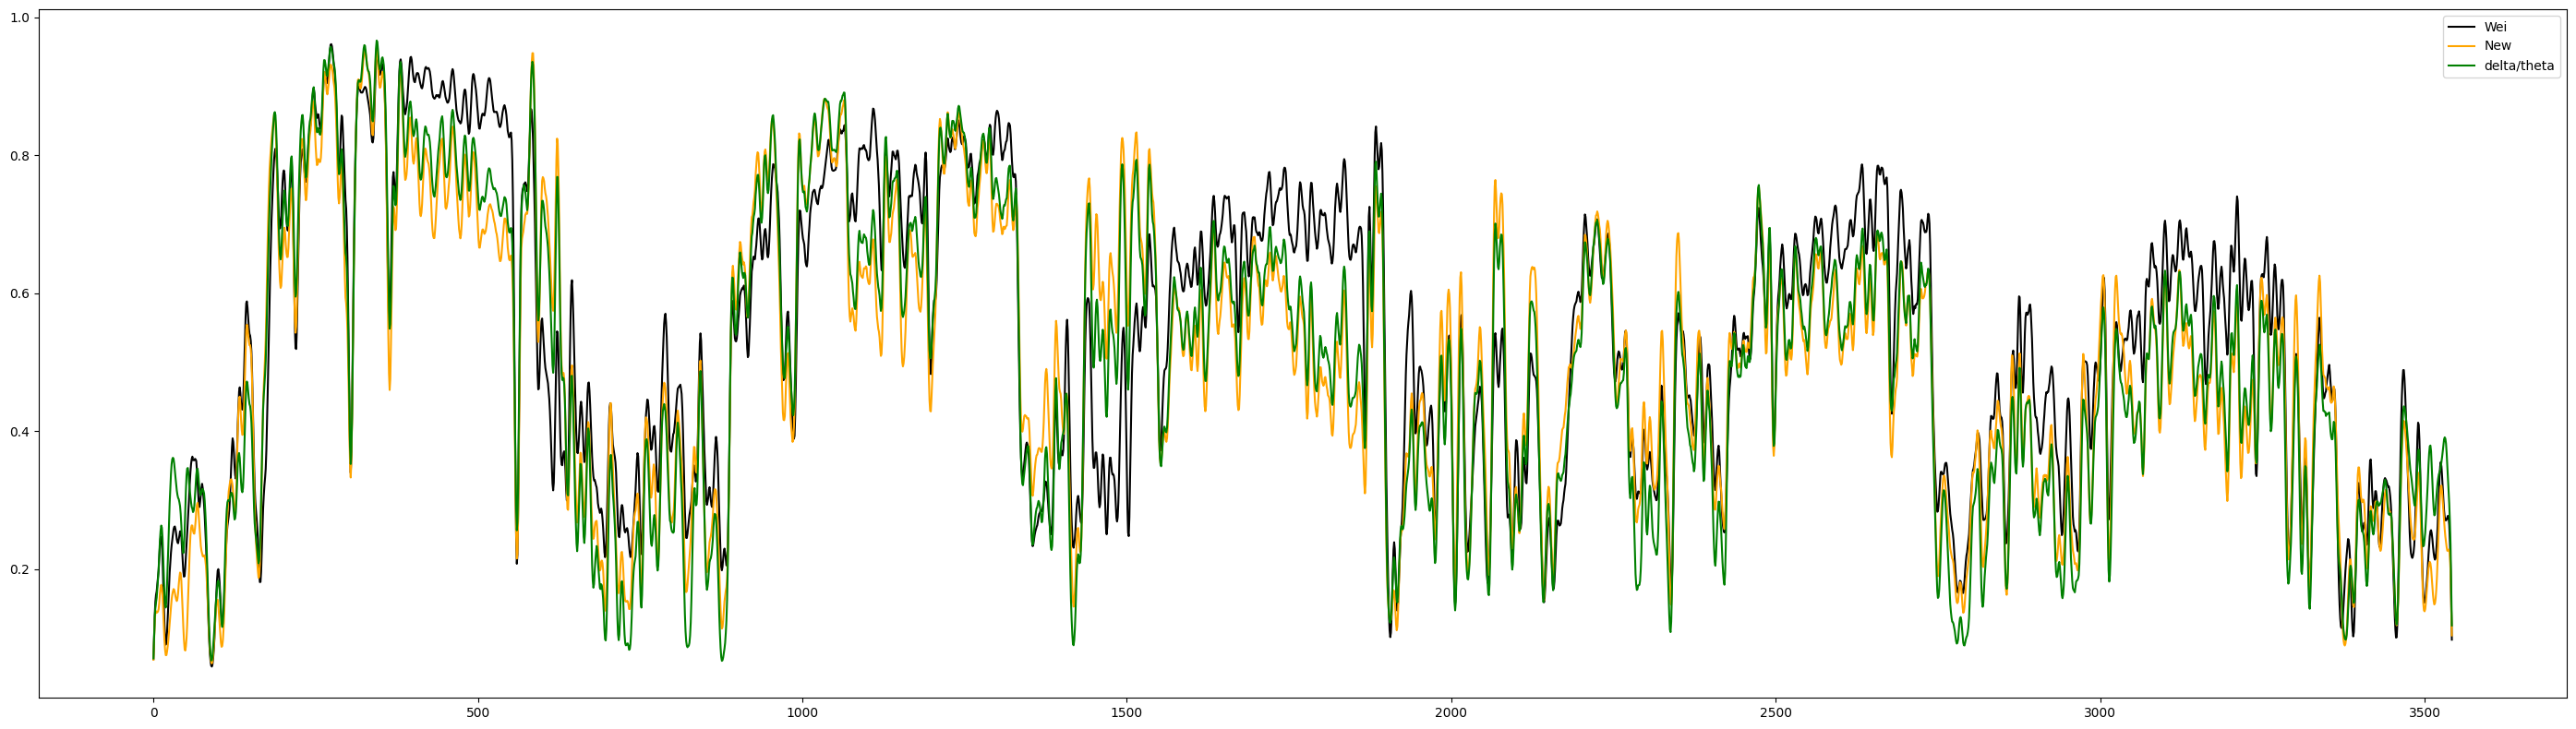

In [88]:
fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_n_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_n_smoothed, label='New', color = 'orange')
ax1.plot(epochs, nindex_nv2_smoothed, label='delta/theta', color = 'green')

# Add legendsg
ax1.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "index-n_wei-vs-new.svg"), format="svg")

# Show the plots
plt.show()

##### All indices plot

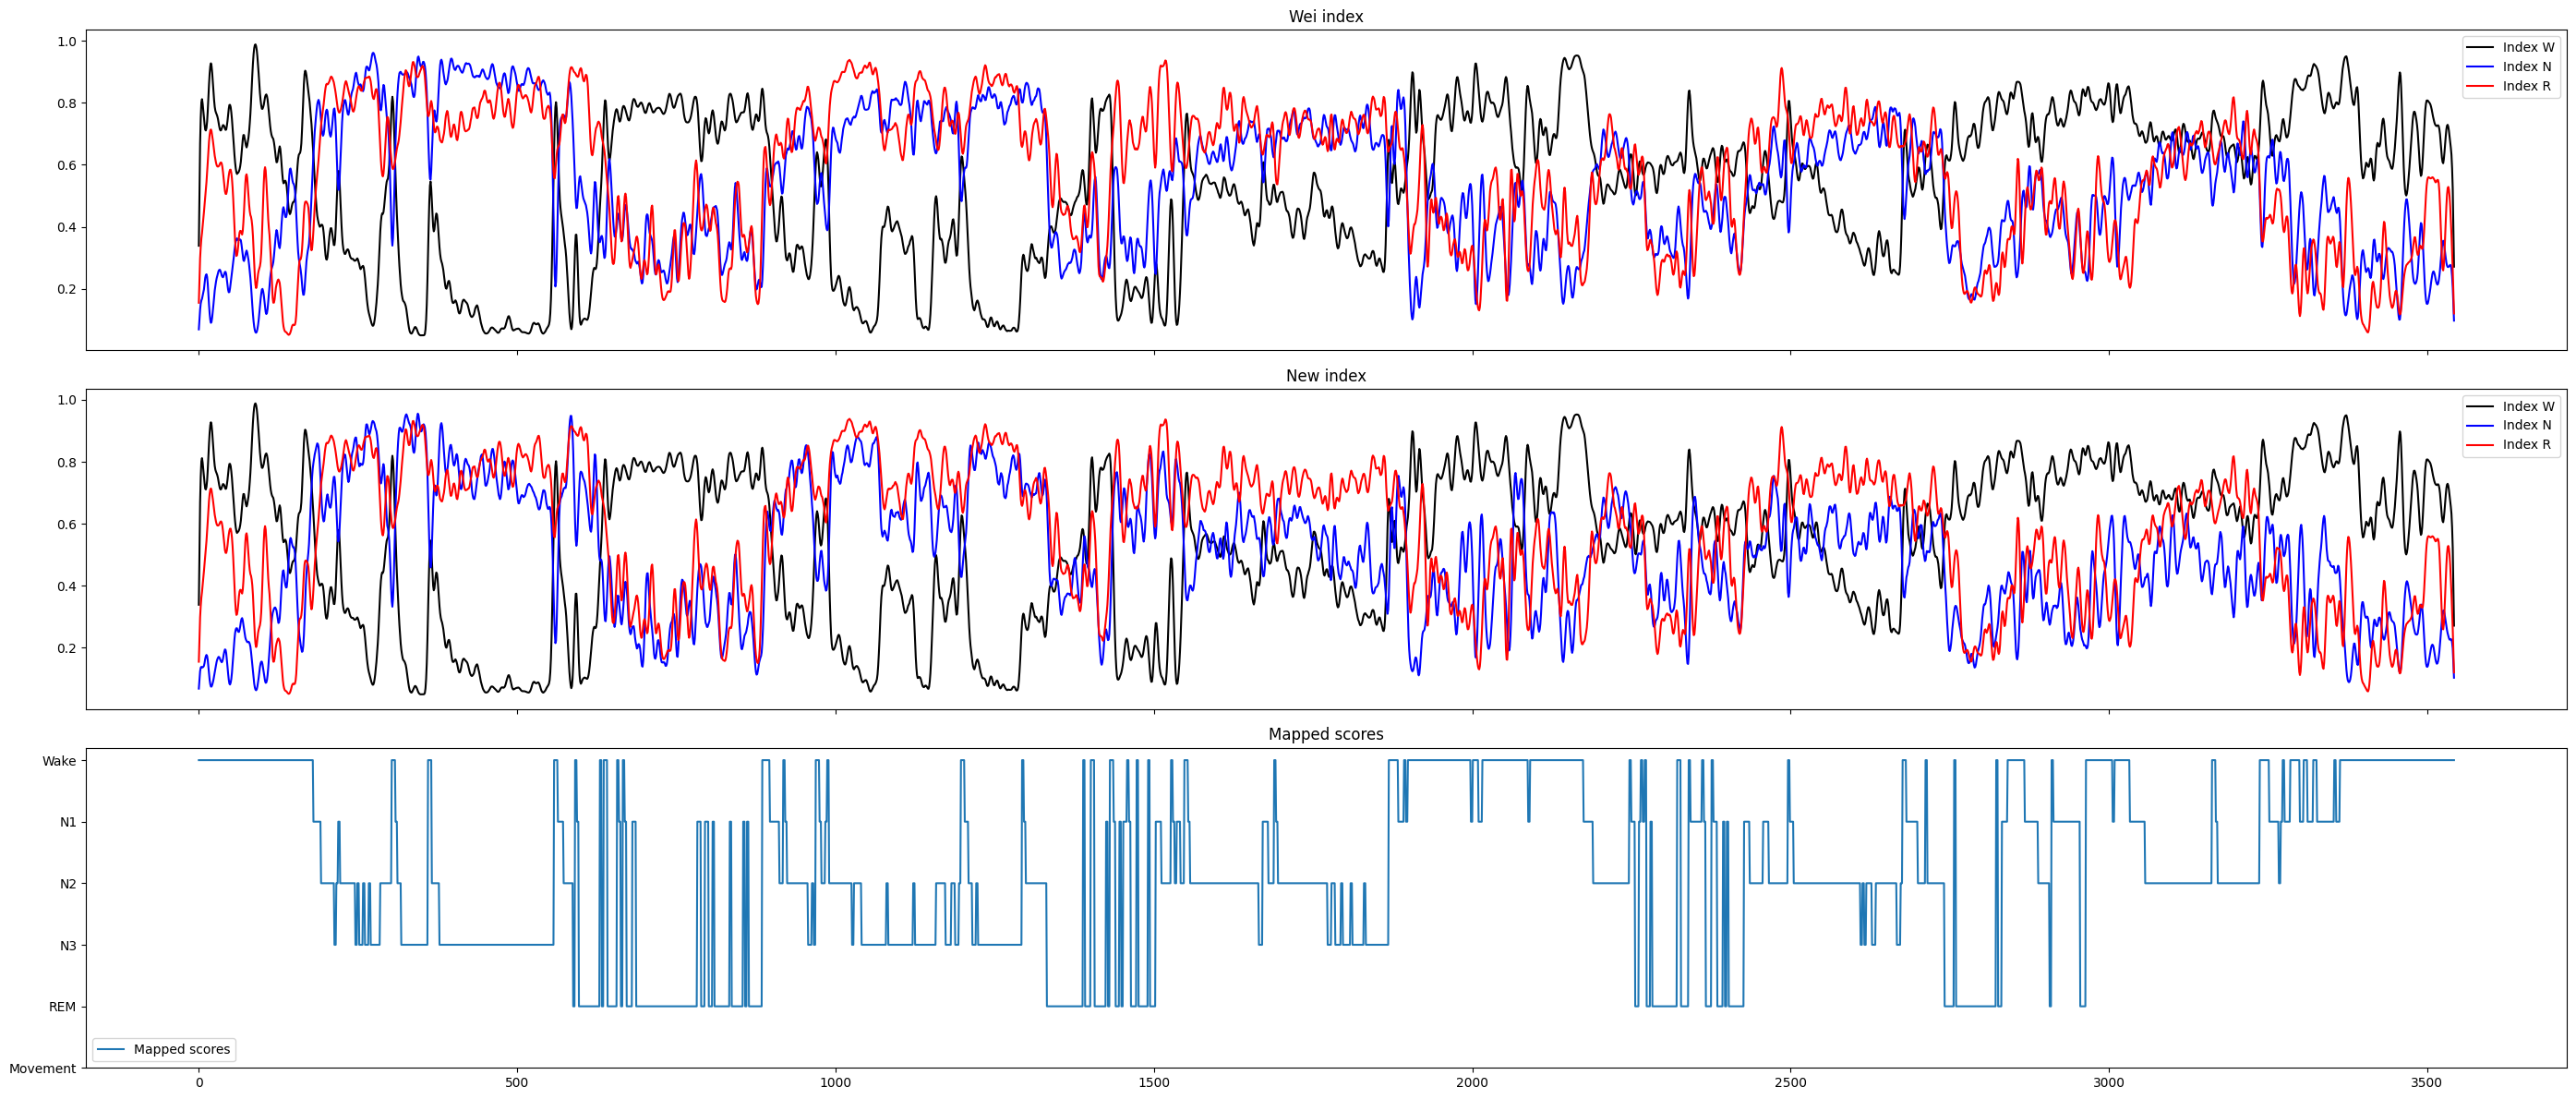

In [89]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, nindex_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, index_r_smoothed, label='Index R', color ='red')


ax3.plot(epochs, majority_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')
ax3.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax3.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "index-n_wei-vs-new_all-indices.svg"), format="svg")

# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [90]:
# New
nindex_Wake = [[],[],[]]
nindex_N1 = [[],[],[]]
nindex_N2 = [[],[],[]]
nindex_N3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(index_w_smoothed[i])
    nindex_Wake[1].append(index_r_smoothed[i])
    nindex_Wake[2].append(nindex_n_smoothed[i])

  elif el == 'N1':
    nindex_N1[0].append(index_w_smoothed[i])
    nindex_N1[1].append(index_r_smoothed[i])
    nindex_N1[2].append(nindex_n_smoothed[i])

  elif el == 'N2':
    nindex_N2[0].append(index_w_smoothed[i])
    nindex_N2[1].append(index_r_smoothed[i])
    nindex_N2[2].append(nindex_n_smoothed[i])

  elif el == 'N3':
    nindex_N3[0].append(index_w_smoothed[i])
    nindex_N3[1].append(index_r_smoothed[i])
    nindex_N3[2].append(nindex_n_smoothed[i])

  elif el == 'REM':
    nindex_REM[0].append(index_w_smoothed[i])
    nindex_REM[1].append(index_r_smoothed[i])
    nindex_REM[2].append(nindex_n_smoothed[i])

In [91]:
# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nN1_w = np.average(nindex_N1[0])
nN1_r = np.average(nindex_N1[1])
nN1_n = np.average(nindex_N1[2])
nN2_w = np.average(nindex_N2[0])
nN2_r = np.average(nindex_N2[1])
nN2_n = np.average(nindex_N2[2])
nN3_w = np.average(nindex_N3[0])
nN3_r = np.average(nindex_N3[1])
nN3_n = np.average(nindex_N3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

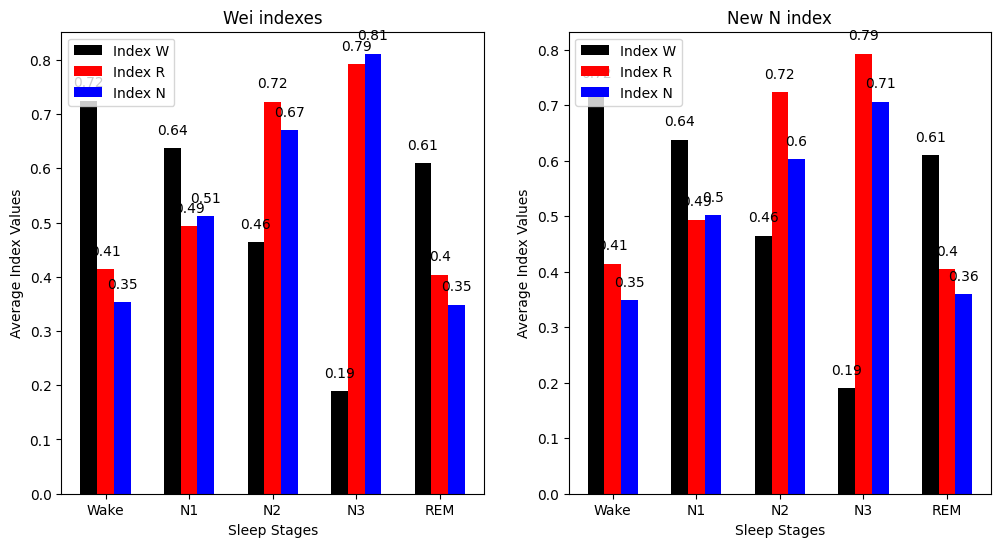

In [92]:
plt.figure(figsize=(12, 6))

# categories = ['Wake', 'N1', "N2", "N3", 'REM']
# index_types = ['Index_w', 'Index_r', 'Index_n']
# values_wake = [nwake_w, nN1_w, nN2_w, nN3_w, nREM_w]
# values_REM = [nwake_r, nN1_r, nN2_r, nN3_r, nREM_r]
# values_NREM = [nwake_n, nN1_n, nN2_n, nN3_n, nREM_n]

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, N1_w, N2_w, N3_w, REM_w]
values_REM = [wake_r, N1_r, N2_r, N3_r, REM_r]
values_NREM = [wake_n, N1_n, N2_n, N3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')




# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nN1_w, nN2_w, nN3_w, nREM_w]
values_REM = [nwake_r, nN1_r, nN2_r, nN3_r, nREM_r]
values_NREM = [nwake_n, nN1_n, nN2_n, nN3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New N index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

plt.savefig(os.path.join(output_path, "index-n_wei-vs-new_all-indices_barplot.svg"), format="svg")

### Comparing Wei vs New

#### Plot

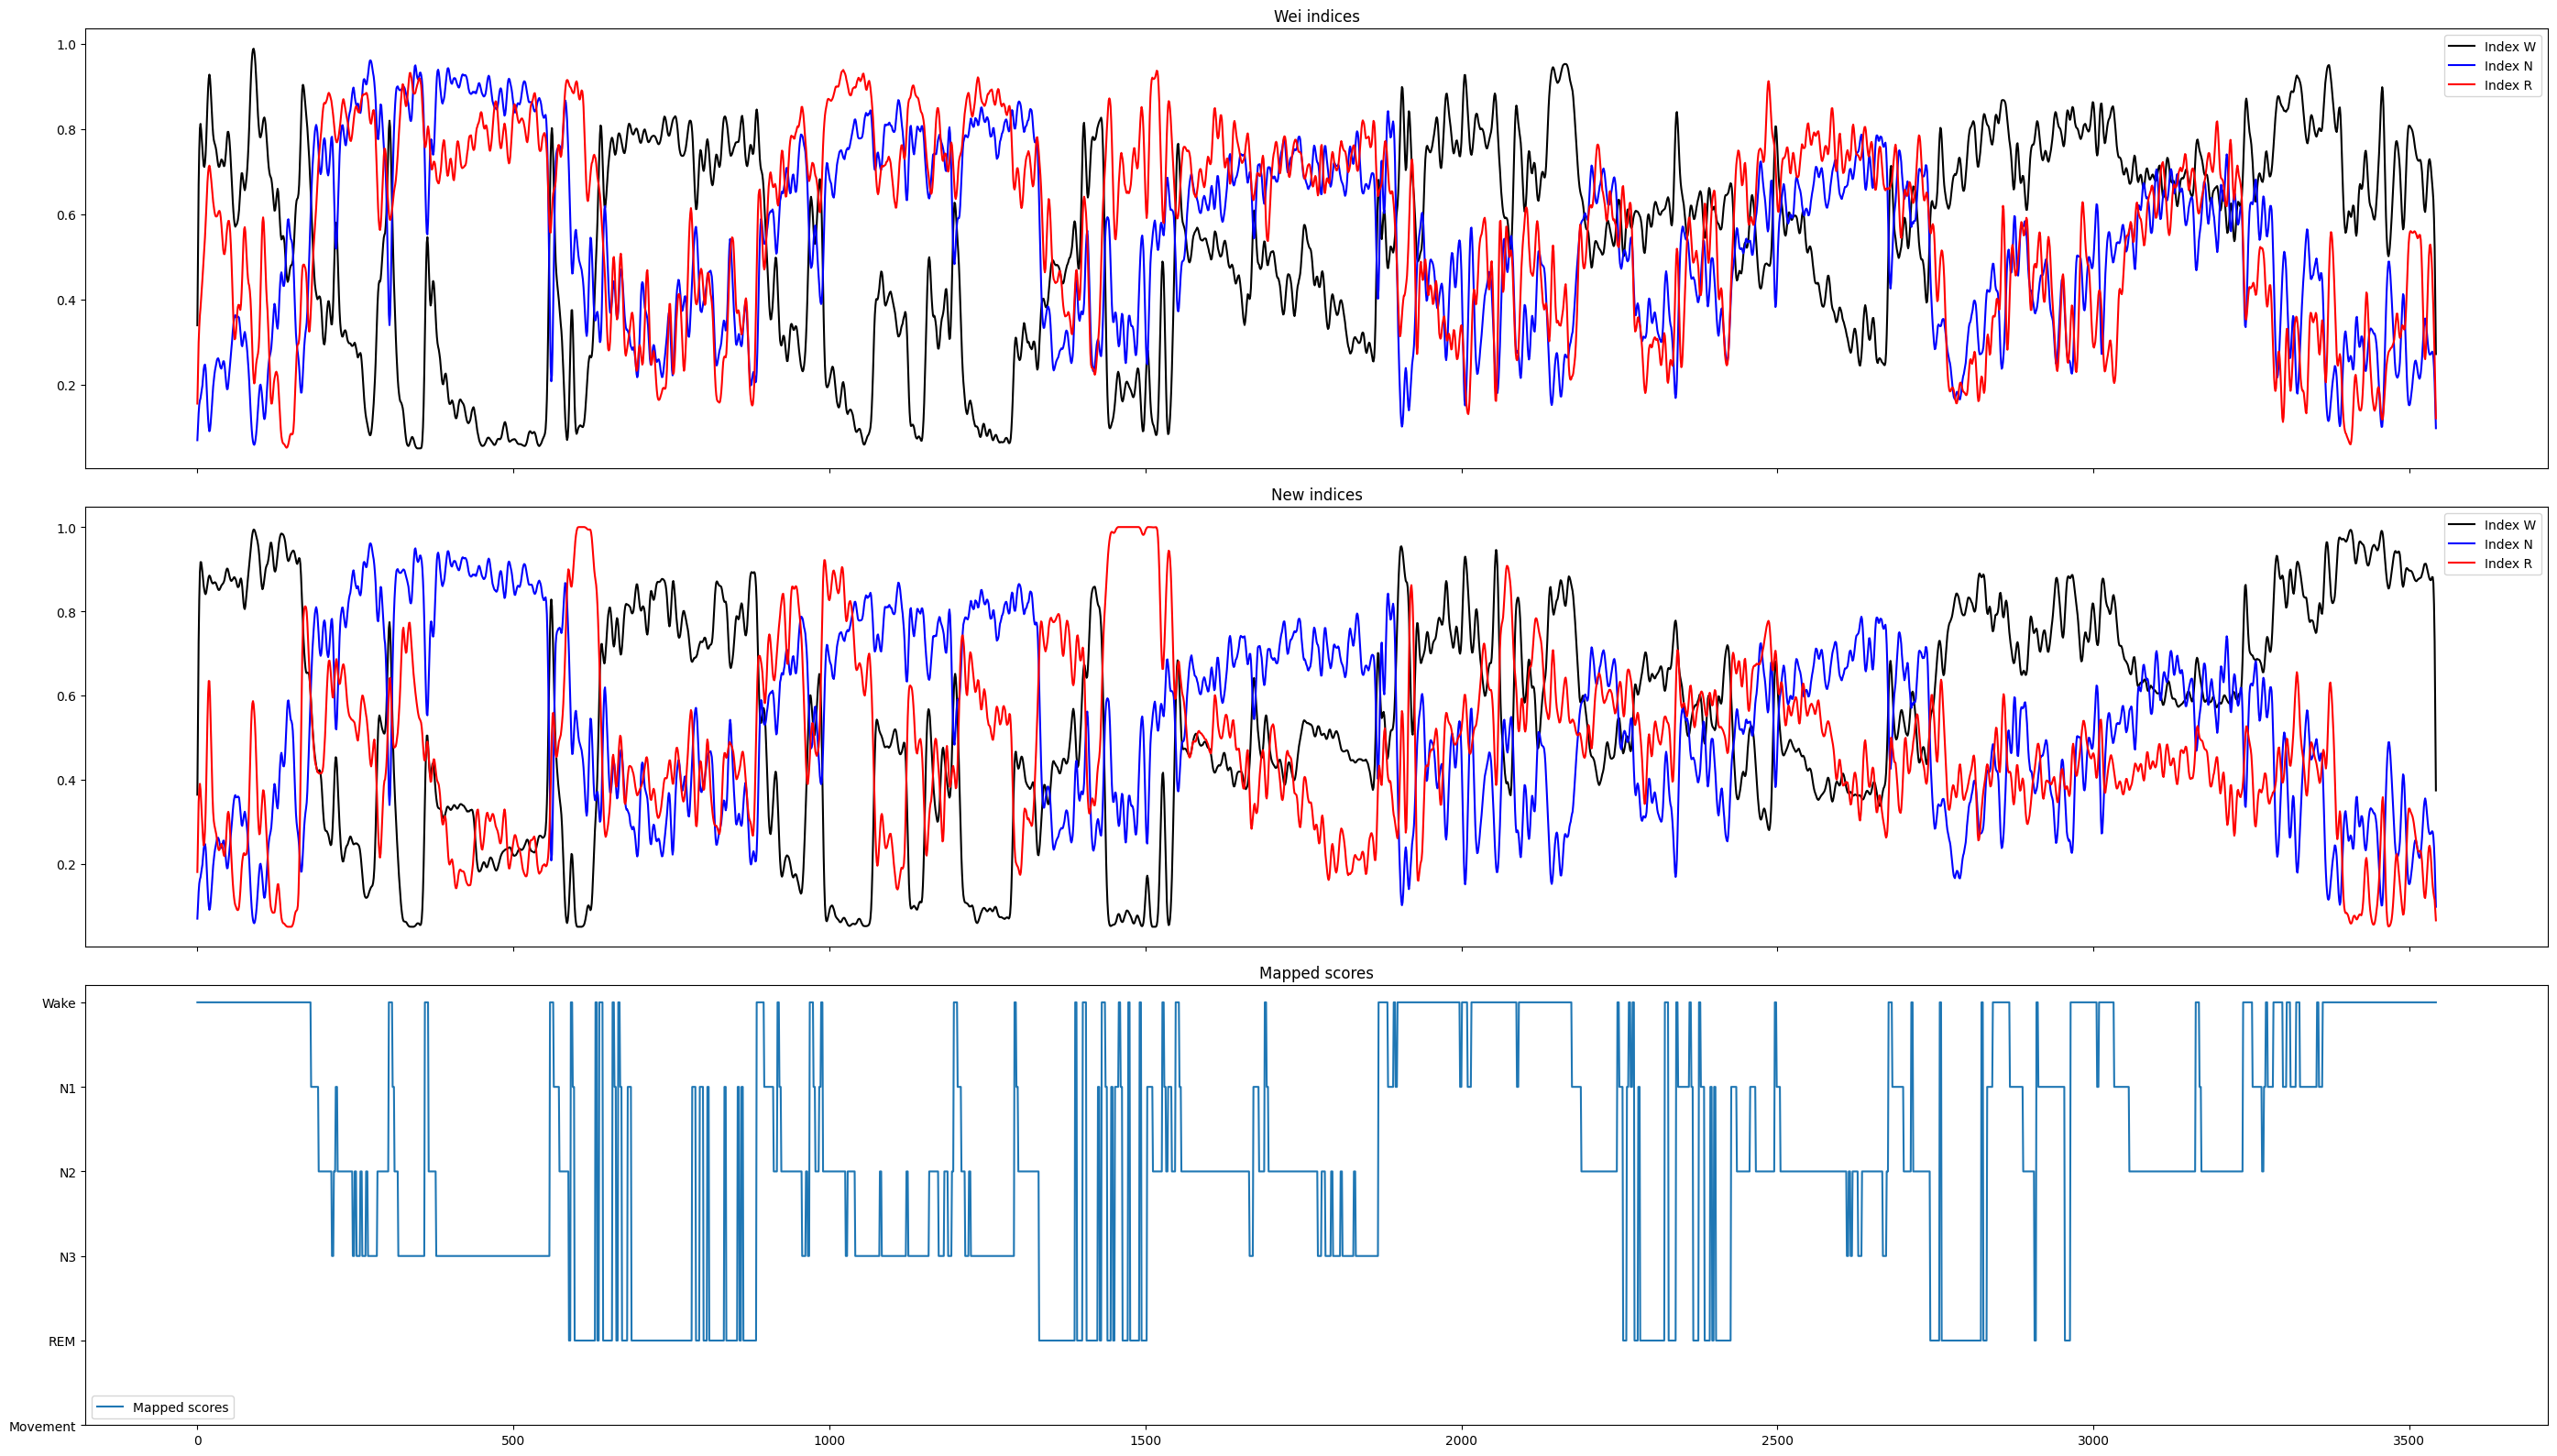

In [93]:
# All main indices
times = np.arange(0, len(epochs))
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 16))

# Plot data on each subplot
ax1.plot(epochs[times], index_w_smoothed[times], label='Index W', color='black')
ax1.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax1.plot(epochs[times], index_r_smoothed[times], label='Index R', color='red')

ax2.plot(epochs[times], nindex_w_smoothed[times], label='Index W', color='black')
ax2.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax2.plot(epochs[times], nindex_r_smoothed[times], label='Index R', color='red')

ax3.plot(epochs[times], majority_scores[times], label='Mapped scores')



# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei indices')
ax2.set_title('New indices')
ax3.set_title('Mapped scores')
ax3.set_yticks(ticks=[0,1,2,3,4,5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax3.invert_yaxis()

# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(os.path.join(output_path, "wei-indices_vs_new-indices.svg"), format="svg")

# Show the plots
plt.show()

#### Barplots

###### Prerequisites

In [94]:
# New
nindex_Wake = [[],[],[]]
nindex_N1 = [[],[],[]]
nindex_N2 = [[],[],[]]
nindex_N3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(nindex_w_smoothed[i])
    nindex_Wake[1].append(nindex_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_N1[0].append(nindex_w_smoothed[i])
    nindex_N1[1].append(nindex_r_smoothed[i])
    nindex_N1[2].append(index_n_smoothed[i])

  elif el == 'N2':
    nindex_N2[0].append(nindex_w_smoothed[i])
    nindex_N2[1].append(nindex_r_smoothed[i])
    nindex_N2[2].append(index_n_smoothed[i])

  elif el == 'N3':
    nindex_N3[0].append(nindex_w_smoothed[i])
    nindex_N3[1].append(nindex_r_smoothed[i])
    nindex_N3[2].append(index_n_smoothed[i])

  elif el == 'REM':
    nindex_REM[0].append(nindex_w_smoothed[i])
    nindex_REM[1].append(nindex_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [95]:
# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nN1_w = np.average(nindex_N1[0])
nN1_r = np.average(nindex_N1[1])
nN1_n = np.average(nindex_N1[2])
nN2_w = np.average(nindex_N2[0])
nN2_r = np.average(nindex_N2[1])
nN2_n = np.average(nindex_N2[2])
nN3_w = np.average(nindex_N3[0])
nN3_r = np.average(nindex_N3[1])
nN3_n = np.average(nindex_N3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

In [96]:
if 'Wake' not in mapped_scores:
  nwake_w = 0
  nwake_r = 0
  nwake_n = 0
if 'REM' not in mapped_scores:
  nREM_w = 0
  nREM_r = 0
  nREM_n = 0
if 'N1' not in mapped_scores:
  nN1_w = 0
  nN1_r = 0
  nN1_n = 0
if 'N2' not in mapped_scores:
  nN2_w = 0
  nN2_r = 0
  nN2_n = 0
if 'N3' not in mapped_scores:
  nN3_w = 0
  nN3_r = 0
  nN3_n = 0

###### Barplots

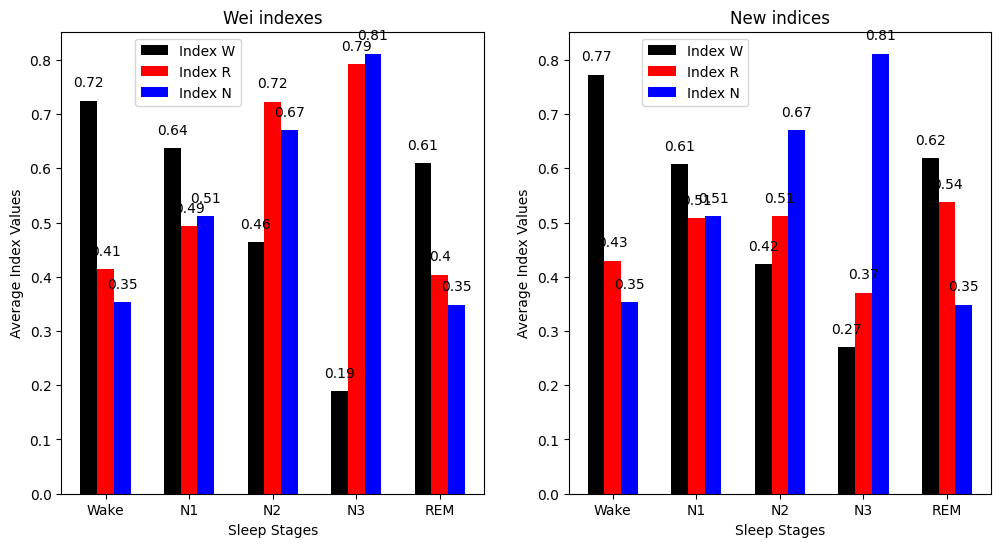

In [97]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, N1_w, N2_w, N3_w, REM_w]
values_REM = [wake_r, N1_r, N2_r, N3_r, REM_r]
values_NREM = [wake_n, N1_n, N2_n, N3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')




# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', "N2", "N3", 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nN1_w, nN2_w, nN3_w, nREM_w]
values_REM = [nwake_r, nN1_r, nN2_r, nN3_r, nREM_r]
values_NREM = [nwake_n, nN1_n, nN2_n, nN3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New indices')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

plt.savefig(os.path.join(output_path, "wei-indices_vs_new-indices_barplot.svg"), format="svg")

plt.show()